# 🥛 Data Preprocessing — Milk Quality Prediction
**Dataset:** milknew.csv (Kaggle: cpluzshrijayan/milkquality)  
**Metode:** K-Means Clustering + Logistic Regression + Naïve Bayes  
**Tahap:** Data Preprocessing


In [1]:
# ── Import Library ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Style plot
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print("✅ Semua library berhasil diimport!")


✅ Semua library berhasil diimport!


## 1. Load Dataset

In [2]:
df = pd.read_csv('milknew.csv')

print(f"Shape  : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"Kolom  : {list(df.columns)}")
print()
df.head(10)


Shape  : 1059 baris × 8 kolom
Kolom  : ['pH', 'Temprature', 'Taste', 'Odor', 'Fat ', 'Turbidity', 'Colour', 'Grade']



,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,high
1,6.6,36,0,1,0,1,253,high
2,8.5,70,1,1,1,1,246,low
3,9.5,34,1,1,0,1,255,low
4,6.6,37,0,0,0,0,255,medium
5,6.6,37,1,1,1,1,255,high
6,5.5,45,1,0,1,1,250,low
7,4.5,60,0,1,1,1,250,low
8,8.1,66,1,0,1,1,255,low
9,6.7,45,1,1,0,0,247,medium


In [3]:
print("=== Info DataFrame ===")
df.info()


=== Info DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pH          1059 non-null   float64
 1   Temprature  1059 non-null   int64  
 2   Taste       1059 non-null   int64  
 3   Odor        1059 non-null   int64  
 4   Fat         1059 non-null   int64  
 5   Turbidity   1059 non-null   int64  
 6   Colour      1059 non-null   int64  
 7   Grade       1059 non-null   object 
dtypes: float64(1), int64(6), object(1)
memory usage: 66.3+ KB


In [4]:
print("=== Statistik Deskriptif ===")
df.describe().round(3)


=== Statistik Deskriptif ===


,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour
count,1059.00,1059.000,1059.000,1059.000,1059.000,1059.000,1059.000
mean,6.63,44.227,0.547,0.432,0.671,0.491,251.840
std,1.40,10.098,0.498,0.496,0.470,0.500,4.307
min,3.00,34.000,0.000,0.000,0.000,0.000,240.000
25%,6.50,38.000,0.000,0.000,0.000,0.000,250.000
50%,6.70,41.000,1.000,0.000,1.000,0.000,255.000
75%,6.80,45.000,1.000,1.000,1.000,1.000,255.000
max,9.50,90.000,1.000,1.000,1.000,1.000,255.000


## 2. Pemeriksaan Missing Values

     Kolom  Jumlah Missing  Persentase (%)
        pH               0             0.0
Temprature               0             0.0
     Taste               0             0.0
      Odor               0             0.0
      Fat                0             0.0
 Turbidity               0             0.0
    Colour               0             0.0
     Grade               0             0.0


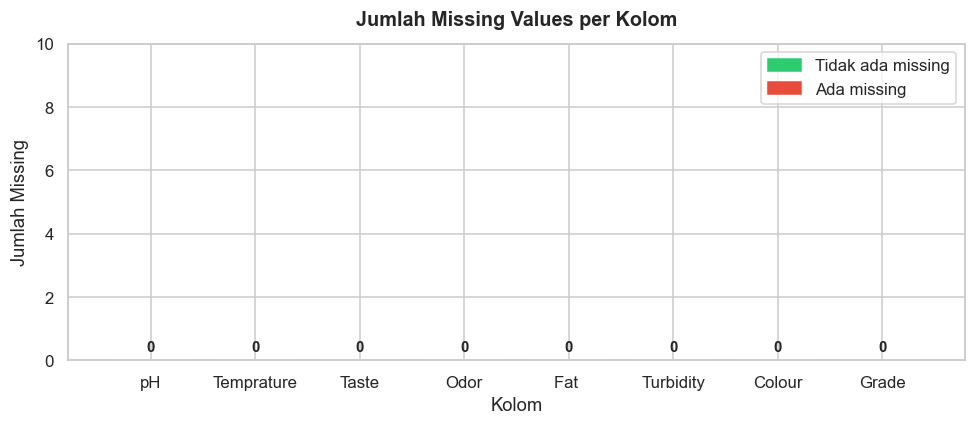

✅ Tidak ditemukan missing value.


In [5]:
missing = df.isnull().sum().reset_index()
missing.columns = ['Kolom', 'Jumlah Missing']
missing['Persentase (%)'] = (missing['Jumlah Missing'] / len(df) * 100).round(2)
print(missing.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71' if v == 0 else '#e74c3c' for v in missing['Jumlah Missing']]
bars = ax.bar(missing['Kolom'], missing['Jumlah Missing'], color=colors, edgecolor='white', linewidth=1.2)
ax.set_title('Jumlah Missing Values per Kolom', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Kolom')
ax.set_ylabel('Jumlah Missing')
ax.set_ylim(0, max(missing['Jumlah Missing'].max() + 5, 10))
for bar, val in zip(bars, missing['Jumlah Missing']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)
patch_ok  = mpatches.Patch(color='#2ecc71', label='Tidak ada missing')
patch_err = mpatches.Patch(color='#e74c3c', label='Ada missing')
ax.legend(handles=[patch_ok, patch_err], loc='upper right')
plt.tight_layout()
plt.savefig('plot_missing_values.png', bbox_inches='tight')
plt.show()
print("✅ Tidak ditemukan missing value.")


## 3. Pemeriksaan & Penghapusan Duplikasi

Jumlah baris sebelum  : 1059
Jumlah baris duplikat : 976
Jumlah baris sesudah  : 83


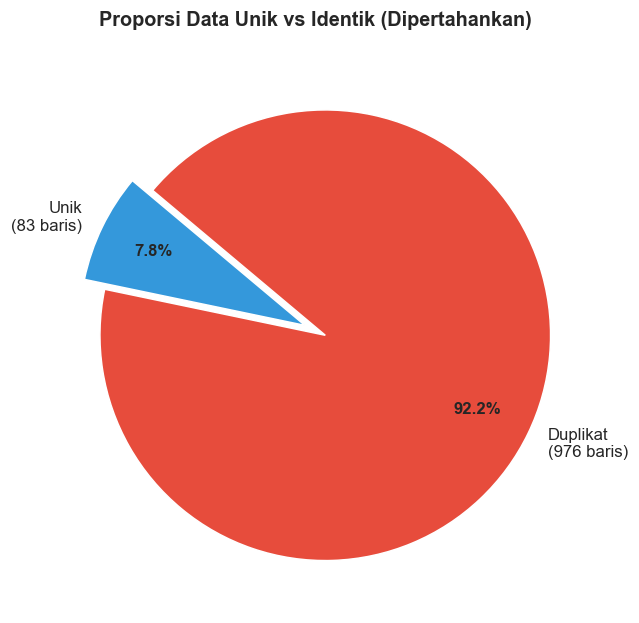


✅ Data duplikat DIPERTAHANKAN. Shape tetap: (1059, 8)
📌 Alasan: Setiap baris adalah catatan validasi kualitas susu yang sah,
   bukan artefak teknis. Menghapusnya akan mengurangi representasi data nyata.


In [6]:
n_before  = len(df)
n_dup     = df.duplicated().sum()
n_after   = n_before - n_dup

print(f"Jumlah baris sebelum  : {n_before}")
print(f"Jumlah baris duplikat : {n_dup}")
print(f"Jumlah baris sesudah  : {n_after}")

# Pie chart
fig, ax = plt.subplots(figsize=(6, 6))
sizes  = [n_after, n_dup]
labels = [f'Unik\n({n_after} baris)', f'Duplikat\n({n_dup} baris)']
colors = ['#3498db', '#e74c3c']
explode = (0.05, 0.05)
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, explode=explode,
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 11}, pctdistance=0.75)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Proporsi Data Unik vs Identik (Dipertahankan)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_duplikasi.png', bbox_inches='tight')
plt.show()

# Duplikat DIPERTAHANKAN — setiap baris merepresentasikan sampel uji kualitas susu
# yang valid secara domain (pengukuran berulang pada kondisi serupa adalah hal wajar)
df_clean = df.copy().reset_index(drop=True)
print(f"\n✅ Data duplikat DIPERTAHANKAN. Shape tetap: {df_clean.shape}")
print("📌 Alasan: Setiap baris adalah catatan validasi kualitas susu yang sah,")
print("   bukan artefak teknis. Menghapusnya akan mengurangi representasi data nyata.")


## 4. Distribusi Kelas (Grade)

 Grade  Jumlah  Persentase (%)
   low     429            40.5
medium     374            35.3
  high     256            24.2


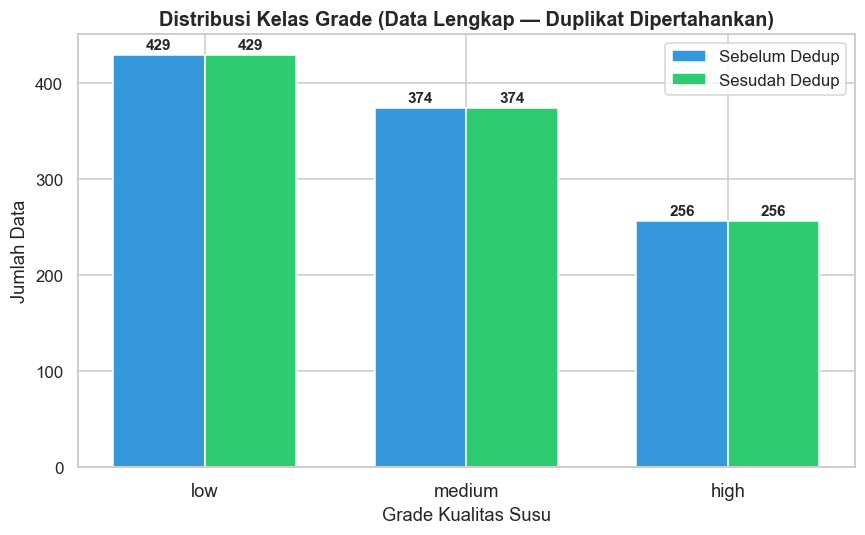

In [7]:
# Data duplikat dipertahankan, sehingga distribusi Grade tidak berubah
grade_dist = df_clean['Grade'].value_counts().reset_index()
grade_dist.columns = ['Grade', 'Jumlah']
grade_dist['Persentase (%)'] = (grade_dist['Jumlah'] / grade_dist['Jumlah'].sum() * 100).round(1)
dist = grade_dist  # alias agar kode visualisasi di bawah tetap jalan
dist['Sebelum Dedup'] = dist['Jumlah']
dist['Sesudah Dedup'] = dist['Jumlah']
print(dist[['Grade','Jumlah','Persentase (%)']].to_string(index=False))

# Side-by-side bar
x     = np.arange(len(dist))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, dist['Sebelum Dedup'], width, label='Sebelum Dedup',
            color='#3498db', edgecolor='white')
b2 = ax.bar(x + width/2, dist['Sesudah Dedup'], width, label='Sesudah Dedup',
            color='#2ecc71', edgecolor='white')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(bar.get_height())), ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(dist['Grade'], fontsize=12)
ax.set_xlabel('Grade Kualitas Susu')
ax.set_ylabel('Jumlah Data')
ax.set_title('Distribusi Kelas Grade (Data Lengkap — Duplikat Dipertahankan)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_distribusi_grade.png', bbox_inches='tight')
plt.show()


## 5. Deteksi Outlier (Metode IQR)

     Kolom    Q1    Q3  IQR  Lower Bound  Upper Bound  Jumlah Outlier       Keputusan
        pH   6.5   6.8  0.3         6.05         7.25             379 Dipertahankan ✅
Temprature  38.0  45.0  7.0        27.50        55.50             103 Dipertahankan ✅
    Colour 250.0 255.0  5.0       242.50       262.50              32 Dipertahankan ✅


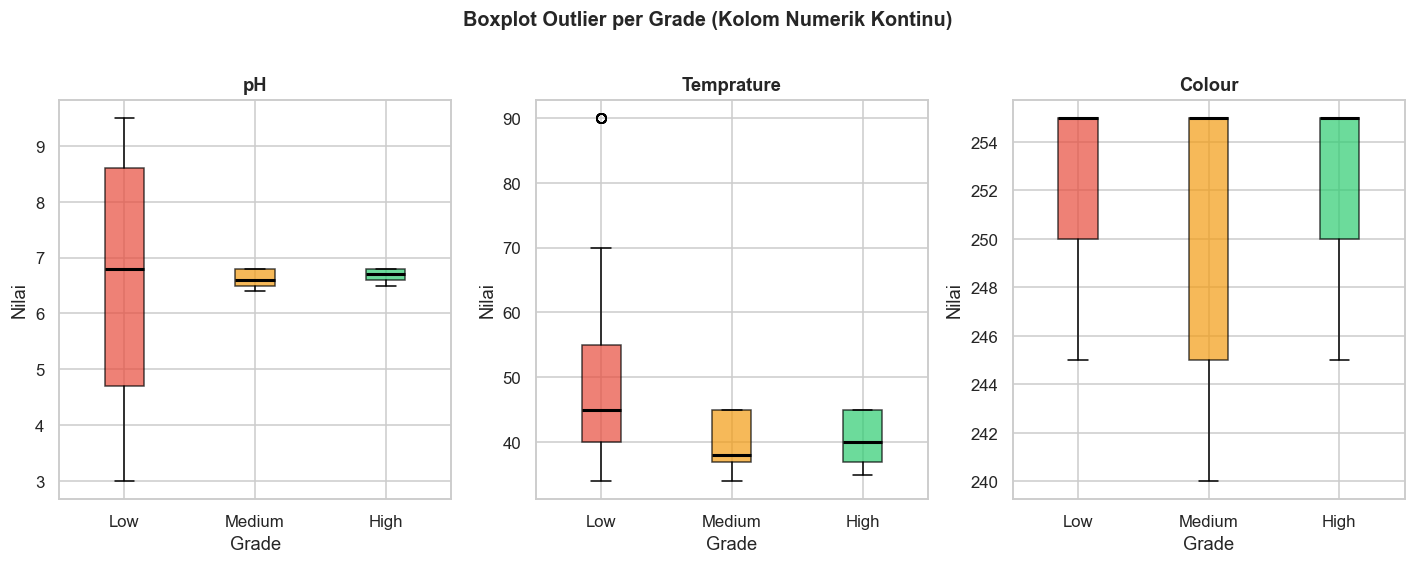


📌 Outlier DIPERTAHANKAN — nilai ekstrem pH/Temprature berkaitan dengan susu kualitas rendah (domain-valid).


In [8]:
# Rename kolom 'Fat ' (ada trailing space)
df_clean = df_clean.rename(columns={'Fat ': 'Fat'})

numeric_cols = ['pH', 'Temprature', 'Colour']

# Tabel ringkasan outlier
rows = []
for col in numeric_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lb) | (df_clean[col] > ub)).sum()
    rows.append({'Kolom': col, 'Q1': Q1, 'Q3': Q3, 'IQR': round(IQR,2),
                 'Lower Bound': round(lb,2), 'Upper Bound': round(ub,2),
                 'Jumlah Outlier': n_out, 'Keputusan': 'Dipertahankan ✅'})
print(pd.DataFrame(rows).to_string(index=False))

# Boxplot
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(13, 5))
palette = ['#9b59b6', '#e67e22', '#1abc9c']
for ax, col, color in zip(axes, numeric_cols, palette):
    data_by_grade = [df_clean[df_clean['Grade']==g][col].values for g in ['low','medium','high']]
    bp = ax.boxplot(data_by_grade, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], ['#e74c3c','#f39c12','#2ecc71']):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Low','Medium','High'])
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Grade')
    ax.set_ylabel('Nilai')
fig.suptitle('Boxplot Outlier per Grade (Kolom Numerik Kontinu)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_boxplot_outlier.png', bbox_inches='tight')
plt.show()
print("\n📌 Outlier DIPERTAHANKAN — nilai ekstrem pH/Temprature berkaitan dengan susu kualitas rendah (domain-valid).")


## 6. Encoding Label Target (Grade)

Mapping Label Encoding:
  high     → 0
  low      → 1
  medium   → 2

 Grade  Grade_encoded  count
  high              0    256
   low              1    429
medium              2    374


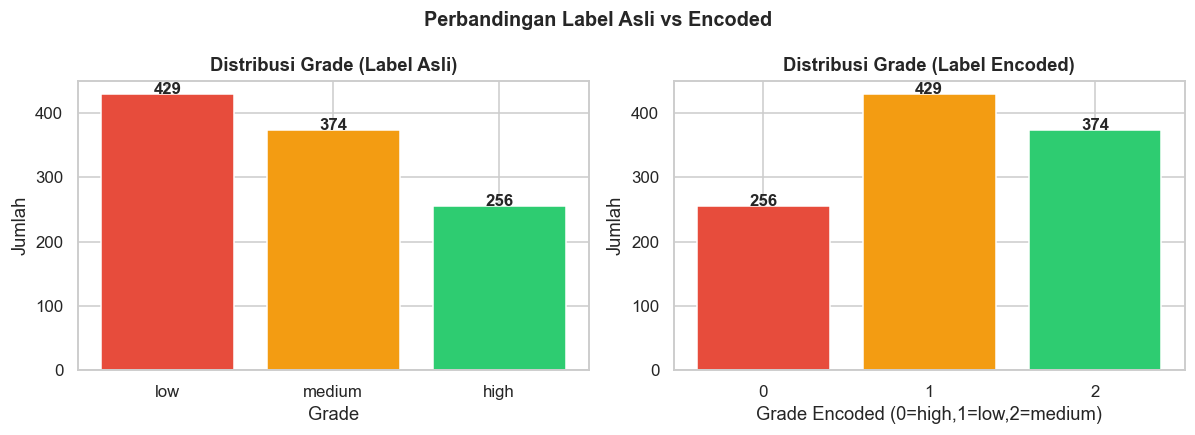

In [9]:
le = LabelEncoder()
df_clean['Grade_encoded'] = le.fit_transform(df_clean['Grade'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping Label Encoding:")
for k, v in mapping.items():
    print(f"  {k:8s} → {v}")
print()
print(df_clean[['Grade','Grade_encoded']].value_counts().reset_index().sort_values('Grade').to_string(index=False))

# Bar chart hasil encoding
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
grade_counts = df_clean['Grade'].value_counts()
grade_enc    = df_clean['Grade_encoded'].value_counts().sort_index()
colors_bar   = ['#e74c3c', '#f39c12', '#2ecc71']

axes[0].bar(grade_counts.index, grade_counts.values, color=colors_bar, edgecolor='white')
axes[0].set_title('Distribusi Grade (Label Asli)', fontweight='bold')
axes[0].set_xlabel('Grade'); axes[0].set_ylabel('Jumlah')
for i, (lbl, val) in enumerate(grade_counts.items()):
    axes[0].text(i, val+0.3, str(val), ha='center', fontweight='bold')

axes[1].bar([str(k) for k in grade_enc.index], grade_enc.values,
            color=colors_bar, edgecolor='white')
axes[1].set_title('Distribusi Grade (Label Encoded)', fontweight='bold')
axes[1].set_xlabel('Grade Encoded (0=high,1=low,2=medium)')
axes[1].set_ylabel('Jumlah')
for i, val in enumerate(grade_enc.values):
    axes[1].text(i, val+0.3, str(val), ha='center', fontweight='bold')

plt.suptitle('Perbandingan Label Asli vs Encoded', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_encoding.png', bbox_inches='tight')
plt.show()


## 7. Feature Scaling

=== Contoh data setelah MinMaxScaler (5 baris) ===
       pH  Temprature  Taste  Odor  Fat  Turbidity  Colour
0  0.5538      0.0179    1.0   0.0  1.0        0.0  0.9333
1  0.5538      0.0357    0.0   1.0  0.0        1.0  0.8667
2  0.8462      0.6429    1.0   1.0  1.0        1.0  0.4000
3  1.0000      0.0000    1.0   1.0  0.0        1.0  1.0000
4  0.5538      0.0536    0.0   0.0  0.0        0.0  1.0000

=== Contoh data setelah StandardScaler (5 baris) ===
       pH  Temprature   Taste    Odor     Fat  Turbidity  Colour
0 -0.0215     -0.9141  0.9105 -0.8730  0.6996    -0.9822  0.5016
1 -0.0215     -0.8150 -1.0983  1.1455 -1.4294     1.0181  0.2693
2  1.3366      2.5534  0.9105  1.1455  0.6996     1.0181 -1.3565
3  2.0514     -1.0132  0.9105  1.1455 -1.4294     1.0181  0.7339
4 -0.0215     -0.7160 -1.0983 -0.8730 -1.4294    -0.9822  0.7339


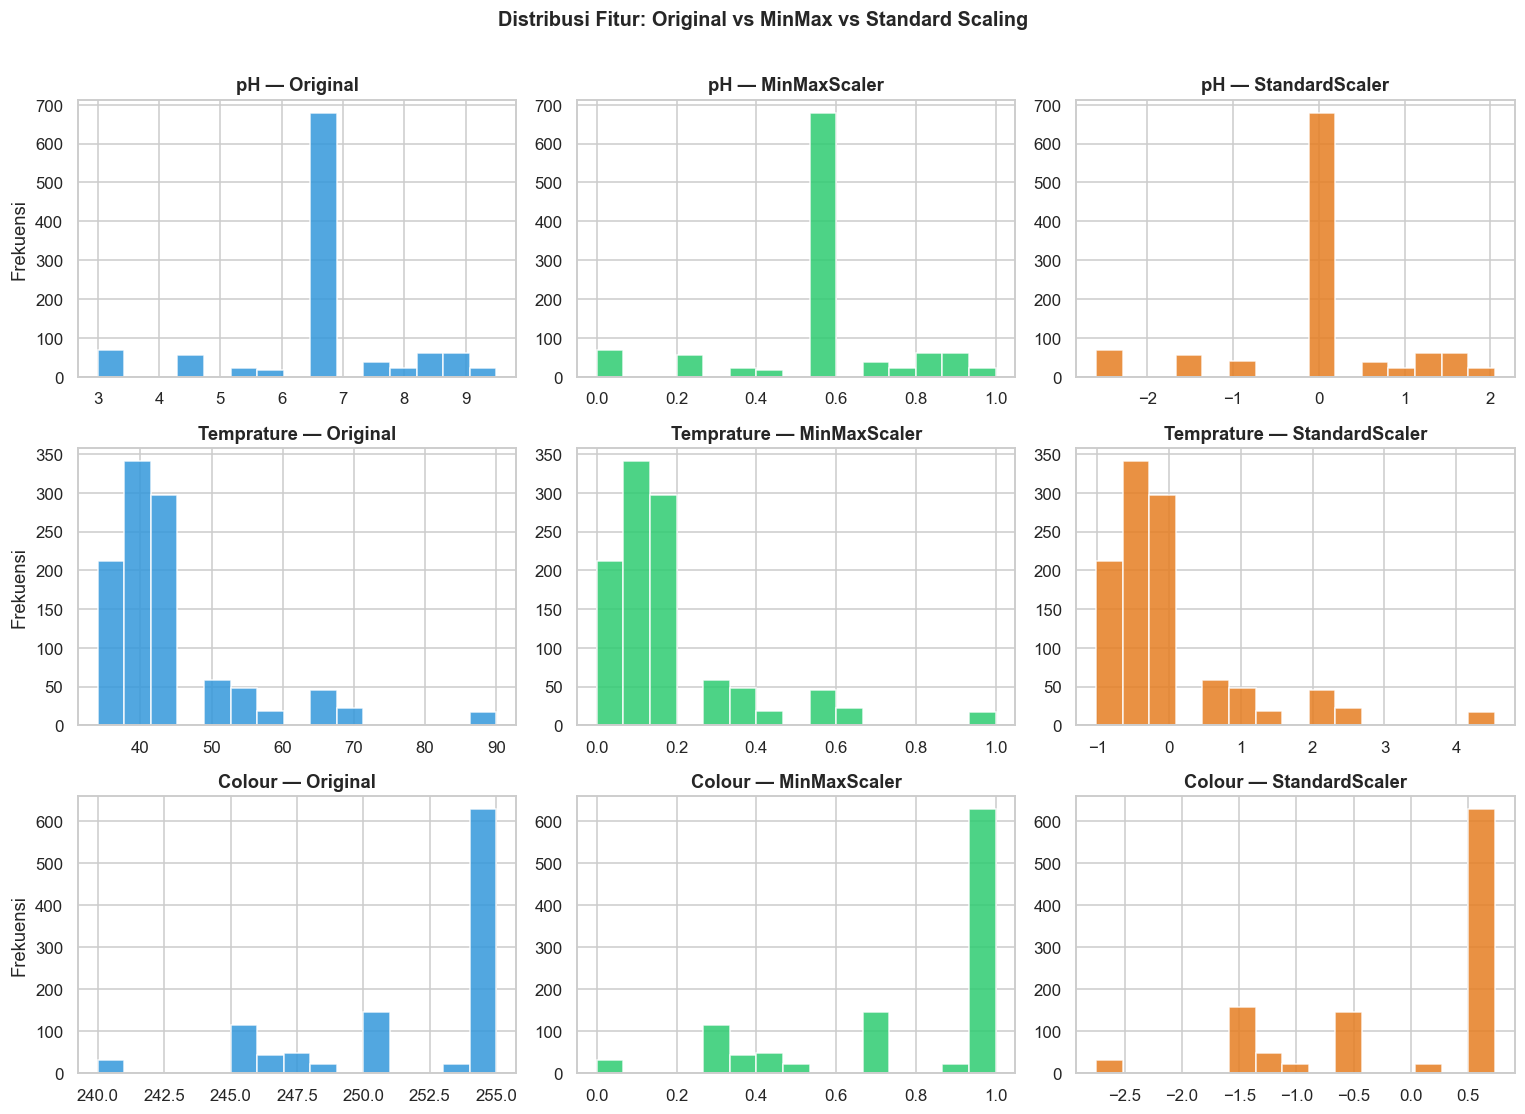


✅ MinMaxScaler → untuk K-Means & Logistic Regression
✅ StandardScaler → untuk Gaussian Naïve Bayes


In [10]:
features = ['pH','Temprature','Taste','Odor','Fat','Turbidity','Colour']

# MinMax Scaler
scaler_mm  = MinMaxScaler()
df_minmax  = df_clean.copy()
df_minmax[features] = scaler_mm.fit_transform(df_clean[features])

# Standard Scaler
scaler_std  = StandardScaler()
df_standard = df_clean.copy()
df_standard[features] = scaler_std.fit_transform(df_clean[features])

print("=== Contoh data setelah MinMaxScaler (5 baris) ===")
print(df_minmax[features].head().round(4).to_string())
print()
print("=== Contoh data setelah StandardScaler (5 baris) ===")
print(df_standard[features].head().round(4).to_string())

# Visualisasi distribusi sebelum vs sesudah scaling (pilih 3 kolom)
viz_cols  = ['pH', 'Temprature', 'Colour']
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, col in enumerate(viz_cols):
    # Before
    axes[i][0].hist(df_clean[col], bins=15, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i][0].set_title(f'{col} — Original', fontweight='bold')
    axes[i][0].set_ylabel('Frekuensi')
    # MinMax
    axes[i][1].hist(df_minmax[col], bins=15, color='#2ecc71', edgecolor='white', alpha=0.85)
    axes[i][1].set_title(f'{col} — MinMaxScaler', fontweight='bold')
    # Standard
    axes[i][2].hist(df_standard[col], bins=15, color='#e67e22', edgecolor='white', alpha=0.85)
    axes[i][2].set_title(f'{col} — StandardScaler', fontweight='bold')

fig.suptitle('Distribusi Fitur: Original vs MinMax vs Standard Scaling',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_scaling_distribusi.png', bbox_inches='tight')
plt.show()
print("\n✅ MinMaxScaler → untuk K-Means & Logistic Regression")
print("✅ StandardScaler → untuk Gaussian Naïve Bayes")


## 8. Analisis Korelasi Fitur

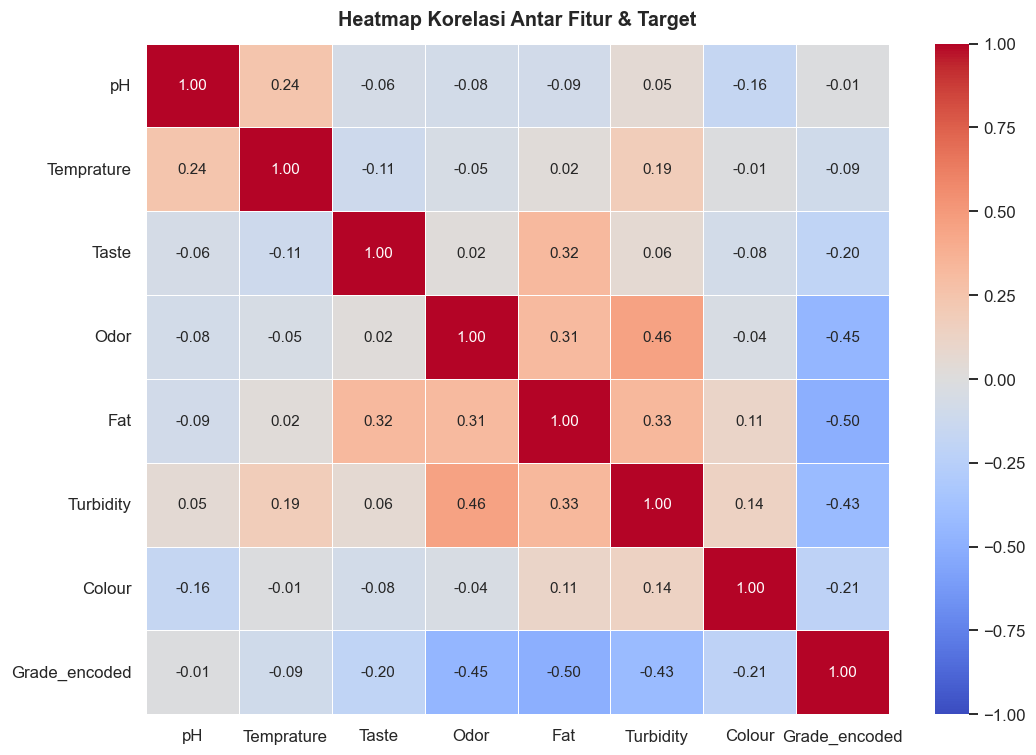

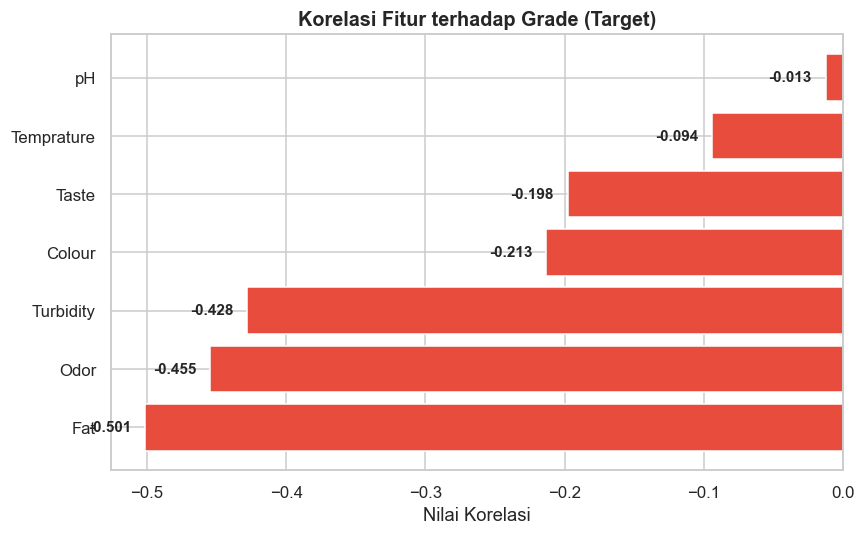


📌 Fat, Odor, dan Turbidity adalah fitur paling berpengaruh terhadap kualitas susu.


In [11]:
corr_matrix = df_clean[features + ['Grade_encoded']].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(10, 7))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 10})
ax.set_title('Heatmap Korelasi Antar Fitur & Target', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot_heatmap_korelasi.png', bbox_inches='tight')
plt.show()

# Bar korelasi vs target
corr_target = corr_matrix['Grade_encoded'].drop('Grade_encoded').sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
colors_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_target]
bars = ax.barh(corr_target.index, corr_target.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=10, fontweight='bold')
ax.set_title('Korelasi Fitur terhadap Grade (Target)', fontsize=13, fontweight='bold')
ax.set_xlabel('Nilai Korelasi')
plt.tight_layout()
plt.savefig('plot_korelasi_target.png', bbox_inches='tight')
plt.show()
print("\n📌 Fat, Odor, dan Turbidity adalah fitur paling berpengaruh terhadap kualitas susu.")


## 9. Simpan Hasil Preprocessing

In [12]:
# Simpan semua versi dataset
df_clean.to_csv('milknew_clean.csv', index=False)
df_minmax.to_csv('milknew_minmax.csv', index=False)
df_standard.to_csv('milknew_standard.csv', index=False)

print("✅ File berhasil disimpan:")
print("   • milknew_clean.csv    — data bersih (tanpa scaling)")
print("   • milknew_minmax.csv   — MinMaxScaler (K-Means & Logistic Regression)")
print("   • milknew_standard.csv — StandardScaler (Naïve Bayes)")
print(f"\nShape final: {df_clean.shape}")
print(f"Kolom: {list(df_clean.columns)}")


✅ File berhasil disimpan:
   • milknew_clean.csv    — data bersih (tanpa scaling)
   • milknew_minmax.csv   — MinMaxScaler (K-Means & Logistic Regression)
   • milknew_standard.csv — StandardScaler (Naïve Bayes)

Shape final: (1059, 9)
Kolom: ['pH', 'Temprature', 'Taste', 'Odor', 'Fat', 'Turbidity', 'Colour', 'Grade', 'Grade_encoded']


## 10. Ringkasan Preprocessing

| Tahap | Aksi | Hasil |
|---|---|---|
| **Load Data** | pd.read_csv | 1.059 baris × 8 kolom |
| **Missing Values** | Pemeriksaan | ✅ Tidak ada missing value |
| **Duplikasi** | Pemeriksaan saja (dipertahankan) | 1.059 baris tetap utuh ✅ |
| **Outlier** | IQR detection | Dipertahankan (domain-valid) |
| **Rename Kolom** | `Fat ` → `Fat` | Trailing space dihapus |
| **Label Encoding** | LabelEncoder pada Grade | high=0, low=1, medium=2 |
| **MinMax Scaling** | MinMaxScaler (0–1) | Untuk K-Means & Logistic Regression |
| **Standard Scaling** | StandardScaler (z-score) | Untuk Naïve Bayes |
| **Analisis Korelasi** | Pearson correlation | Fat & Odor paling signifikan |

> **Catatan:** 976 baris terdeteksi identik secara nilai, namun **dipertahankan** karena setiap baris merepresentasikan hasil pengujian kualitas susu yang valid. Pengukuran berulang pada kondisi serupa adalah hal wajar dalam konteks quality control.


---
## 11. GridSearchCV — Optimasi Hyperparameter

GridSearchCV digunakan untuk mencari kombinasi hyperparameter terbaik secara exhaustive melalui cross-validation.

In [13]:
# ── Import tambahan untuk modelling ────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    silhouette_score, adjusted_rand_score, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA

print('✅ Library modelling berhasil diimport!')

✅ Library modelling berhasil diimport!


In [14]:
# ── Persiapan data dari hasil preprocessing ─────────────────────────────
# Gunakan df_minmax (MinMaxScaler) → untuk Logistic Regression & K-Means
# Gunakan df_standard (StandardScaler) → untuk Naïve Bayes

features = ['pH','Temprature','Taste','Odor','Fat','Turbidity','Colour']
target   = 'Grade_encoded'

X_mm  = df_minmax[features]
X_std = df_standard[features]
y     = df_clean[target]

# Split data (80:20, stratified)
X_train_mm,  X_test_mm,  y_train, y_test = train_test_split(
    X_mm,  y, test_size=0.2, random_state=42, stratify=y)
X_train_std, X_test_std, _,       _      = train_test_split(
    X_std, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train : {X_train_mm.shape[0]} sampel')
print(f'Test  : {X_test_mm.shape[0]}  sampel')
print(f'Kelas : {le.classes_}  →  {list(le.transform(le.classes_))}')

Train : 847 sampel
Test  : 212  sampel
Kelas : ['high' 'low' 'medium']  →  [np.int64(0), np.int64(1), np.int64(2)]


In [15]:
# ── GridSearchCV — Logistic Regression ──────────────────────────────────
param_grid_lr = {
    'C'          : [0.01, 0.1, 1, 10, 100],
    'solver'     : ['lbfgs', 'saga'],
    'max_iter'   : [200, 500]
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_lr.fit(X_train_mm, y_train)

print('=== GridSearchCV — Logistic Regression ===')
print(f'Best Params  : {grid_lr.best_params_}')
print(f'Best CV Acc  : {grid_lr.best_score_:.4f}')

best_lr = grid_lr.best_estimator_

=== GridSearchCV — Logistic Regression ===
Best Params  : {'C': 10, 'max_iter': 200, 'solver': 'lbfgs'}
Best CV Acc  : 0.8513


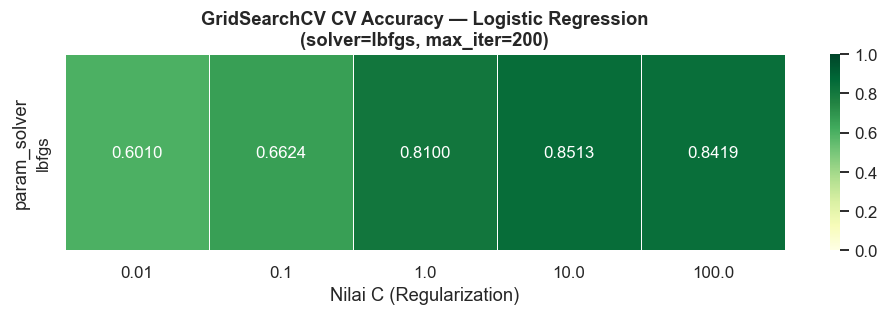

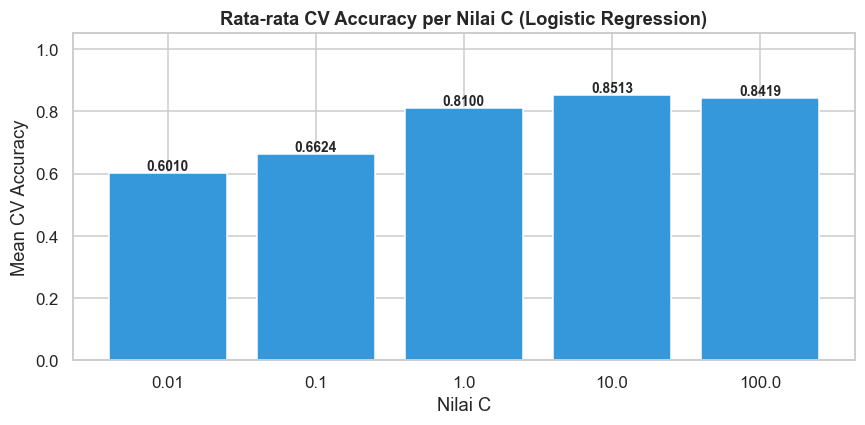

In [16]:
# ── Visualisasi hasil GridSearchCV (heatmap CV score) ───────────────────
import pandas as pd
results_lr = pd.DataFrame(grid_lr.cv_results_)
# Filter hanya solver lbfgs & max_iter=200 untuk heatmap 2D
pivot_lr = results_lr[
    (results_lr['param_solver'] == 'lbfgs') &
    (results_lr['param_max_iter'] == 200)
].pivot_table(
    values='mean_test_score',
    index='param_solver',
    columns='param_C'
)

fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(pivot_lr, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('GridSearchCV CV Accuracy — Logistic Regression\n(solver=lbfgs, max_iter=200)',
             fontweight='bold')
ax.set_xlabel('Nilai C (Regularization)')
plt.tight_layout()
plt.savefig('plot_gridsearch_lr.png', bbox_inches='tight')
plt.show()

# Bar: semua kombinasi C vs mean test score
agg = results_lr.groupby('param_C')['mean_test_score'].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(agg['param_C'].astype(str), agg['mean_test_score'],
       color='#3498db', edgecolor='white')
ax.set_title('Rata-rata CV Accuracy per Nilai C (Logistic Regression)',
             fontweight='bold')
ax.set_xlabel('Nilai C'); ax.set_ylabel('Mean CV Accuracy')
ax.set_ylim(0, 1.05)
for bar, val in zip(ax.patches, agg['mean_test_score']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_gridsearch_C.png', bbox_inches='tight')
plt.show()

---
## 12. K-Means Clustering

K-Means adalah algoritma unsupervised learning yang mengelompokkan data ke dalam **k** cluster berdasarkan kemiripan fitur. Dataset susu memiliki 3 kelas (low/medium/high), sehingga k=3 menjadi pilihan awal yang logis. Metode Elbow dan Silhouette Score digunakan untuk validasi.

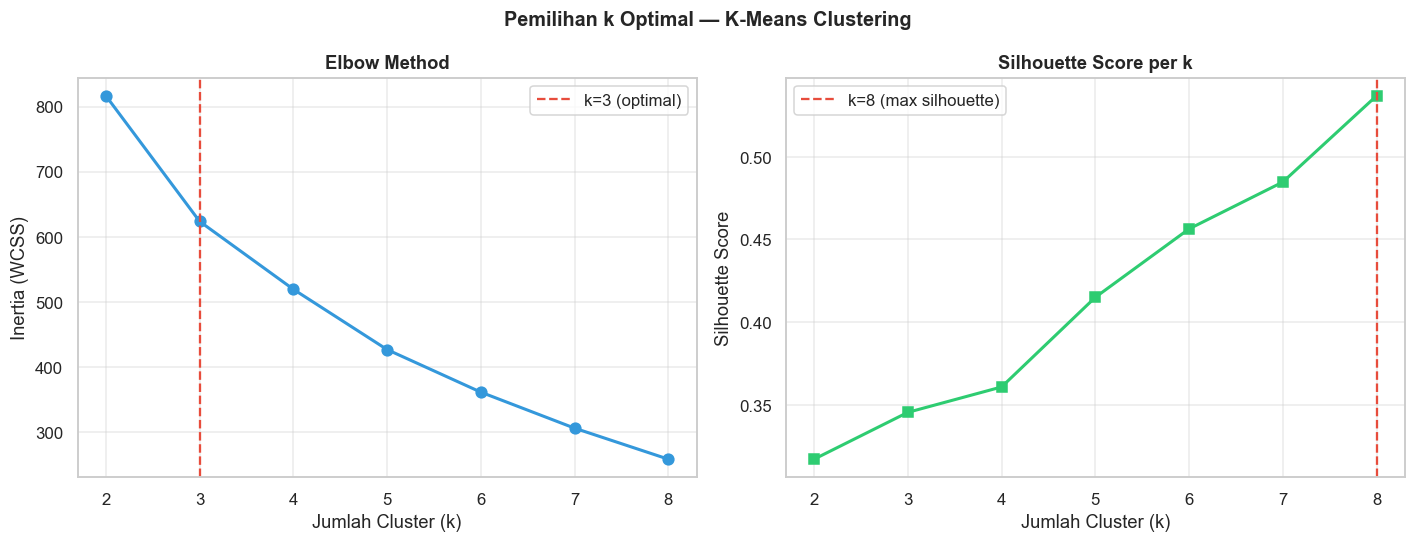

Inertia per k   : {2: 816.48, 3: 623.5, 4: 519.21, 5: 426.58, 6: 361.17, 7: 305.87, 8: 258.23}
Silhouette per k: {2: 0.3172, 3: 0.3455, 4: 0.3609, 5: 0.4151, 6: 0.4564, 7: 0.4847, 8: 0.5368}


In [17]:
# ── Elbow Method — cari k optimal ───────────────────────────────────────
inertia_list = []
sil_list     = []
k_range      = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_mm)
    inertia_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_mm, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow
axes[0].plot(list(k_range), inertia_list, marker='o', color='#3498db',
             linewidth=2, markersize=7)
axes[0].axvline(3, color='#e74c3c', linestyle='--', label='k=3 (optimal)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Silhouette
axes[1].plot(list(k_range), sil_list, marker='s', color='#2ecc71',
             linewidth=2, markersize=7)
axes[1].axvline(k_range[sil_list.index(max(sil_list))], color='#e74c3c',
                linestyle='--', label=f'k={k_range[sil_list.index(max(sil_list))]} (max silhouette)')
axes[1].set_title('Silhouette Score per k', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Pemilihan k Optimal — K-Means Clustering', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('plot_kmeans_elbow.png', bbox_inches='tight')
plt.show()

print(f'Inertia per k   : {dict(zip(k_range, [round(v,2) for v in inertia_list]))}')
print(f'Silhouette per k: {dict(zip(k_range, [round(v,4) for v in sil_list]))}')

In [18]:
# ── GridSearchCV untuk KMeans (n_clusters & n_init) ─────────────────────
# Catatan: KMeans tidak support GridSearchCV langsung via scoring standar.
# Kita buat manual grid dengan Silhouette Score sebagai metrik.

from itertools import product as iterproduct

param_grid_km = {
    'n_clusters': [2, 3, 4, 5],
    'n_init'    : [5, 10, 15],
    'init'      : ['k-means++', 'random']
}

km_results = []
for nc, ni, init in iterproduct(
        param_grid_km['n_clusters'],
        param_grid_km['n_init'],
        param_grid_km['init']):
    km_tmp = KMeans(n_clusters=nc, n_init=ni, init=init, random_state=42)
    labels_tmp = km_tmp.fit_predict(X_mm)
    sil = silhouette_score(X_mm, labels_tmp)
    km_results.append({'n_clusters': nc, 'n_init': ni,
                        'init': init, 'silhouette': round(sil, 4)})

df_km_grid = pd.DataFrame(km_results).sort_values('silhouette', ascending=False)
print('=== Top 10 Konfigurasi KMeans (by Silhouette Score) ===')
print(df_km_grid.head(10).to_string(index=False))

best_km_params = df_km_grid.iloc[0]
print(f'\n✅ Best: n_clusters={int(best_km_params.n_clusters)}, '
      f'n_init={int(best_km_params.n_init)}, '
      f'init={best_km_params.init}, '
      f'silhouette={best_km_params.silhouette}')

=== Top 10 Konfigurasi KMeans (by Silhouette Score) ===
 n_clusters  n_init      init  silhouette
          5      15 k-means++      0.4151
          5      10 k-means++      0.4151
          5       5 k-means++      0.4145
          5      15    random      0.4141
          5      10    random      0.4141
          5       5    random      0.4141
          4       5 k-means++      0.3684
          4      10    random      0.3609
          4      15    random      0.3609
          4      15 k-means++      0.3609

✅ Best: n_clusters=5, n_init=15, init=k-means++, silhouette=0.4151


In [19]:
# ── Fit KMeans dengan k=3 (sesuai jumlah kelas susu) ────────────────────
best_k    = 3
best_init = best_km_params['init']
best_ni   = int(best_km_params['n_init'])

kmeans = KMeans(n_clusters=best_k, n_init=best_ni,
                init=best_init, random_state=42)
cluster_labels = kmeans.fit_predict(X_mm)

df_cluster = df_minmax.copy()
df_cluster['Cluster'] = cluster_labels

sil_final = silhouette_score(X_mm, cluster_labels)
ari_final = adjusted_rand_score(y, cluster_labels)

print(f'Silhouette Score : {sil_final:.4f}')
print(f'Adjusted Rand Index (vs Grade) : {ari_final:.4f}')
print()
print('Distribusi cluster:')
print(df_cluster['Cluster'].value_counts().sort_index().to_string())

Silhouette Score : 0.3455
Adjusted Rand Index (vs Grade) : 0.2408

Distribusi cluster:
Cluster
0    307
1    386
2    366


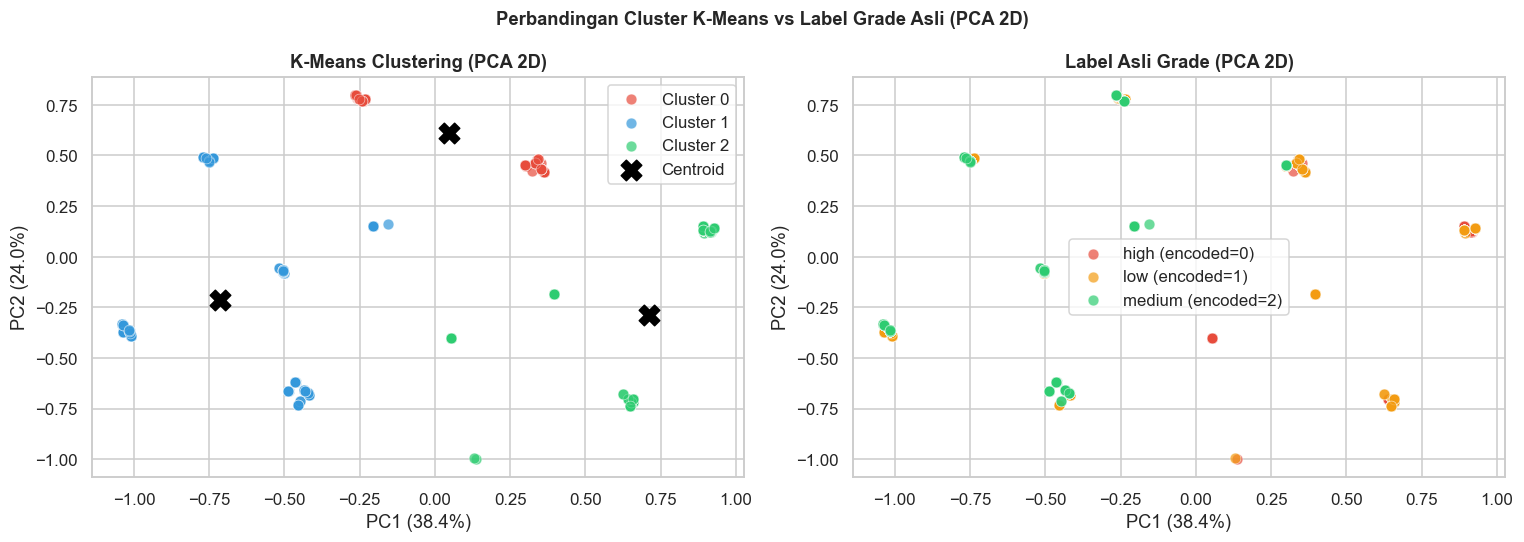


📌 PCA menjelaskan 62.4% variansi total.


In [20]:
# ── Visualisasi Cluster (PCA 2D) ─────────────────────────────────────────
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_mm)

centers_pca = pca2.transform(kmeans.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cluster_colors = ['#e74c3c', '#3498db', '#2ecc71']
grade_colors   = ['#e74c3c', '#f39c12', '#2ecc71']

# Plot cluster hasil KMeans
for c in range(best_k):
    mask_c = cluster_labels == c
    axes[0].scatter(X_pca[mask_c, 0], X_pca[mask_c, 1],
                    c=cluster_colors[c], label=f'Cluster {c}',
                    alpha=0.7, s=50, edgecolors='white', linewidth=0.4)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1],
                c='black', marker='X', s=180, label='Centroid', zorder=5)
axes[0].set_title('K-Means Clustering (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Plot label asli Grade
grade_vals = y.values
for g, gc in zip([0, 1, 2], grade_colors):
    mask_g = grade_vals == g
    lbl = le.inverse_transform([g])[0]
    axes[1].scatter(X_pca[mask_g, 0], X_pca[mask_g, 1],
                    c=gc, label=f'{lbl} (encoded={g})',
                    alpha=0.7, s=50, edgecolors='white', linewidth=0.4)
axes[1].set_title('Label Asli Grade (PCA 2D)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()

plt.suptitle('Perbandingan Cluster K-Means vs Label Grade Asli (PCA 2D)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_kmeans_cluster.png', bbox_inches='tight')
plt.show()

print(f'\n📌 PCA menjelaskan {sum(pca2.explained_variance_ratio_)*100:.1f}% variansi total.')

=== Rata-rata Fitur per Cluster (MinMax Scaled) ===
            pH  Temprature  Taste   Odor    Fat  Turbidity  Colour
Cluster                                                           
0        0.599       0.213  1.000  0.147  1.000      0.365   0.710
1        0.558       0.177  0.223  0.122  0.166      0.163   0.767
2        0.525       0.163  0.508  1.000  0.929      0.943   0.879


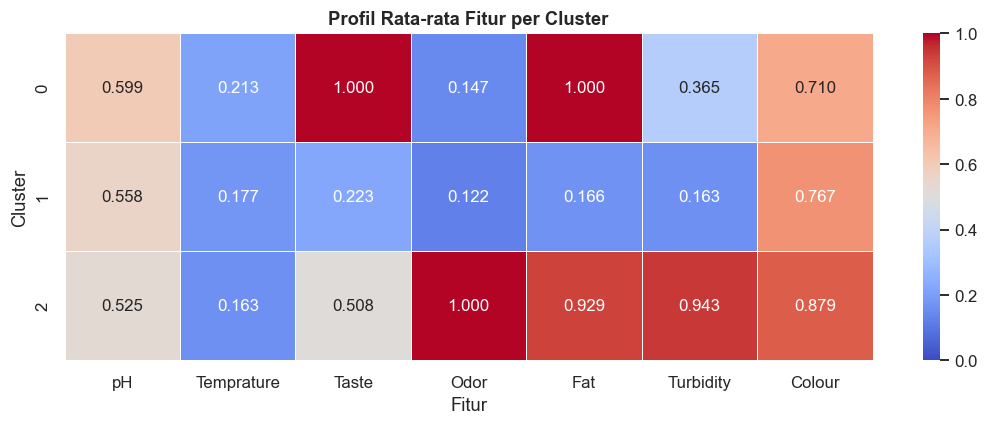


=== Cross-tabulation Cluster vs Grade Asli ===
Grade Asli  high  low  medium
Cluster                      
0             83  136      88
1              0  100     286
2            173  193       0


In [21]:
# ── Profil tiap cluster ──────────────────────────────────────────────────
cluster_profile = df_cluster.groupby('Cluster')[features].mean().round(3)
print('=== Rata-rata Fitur per Cluster (MinMax Scaled) ===')
print(cluster_profile.to_string())

# Heatmap profil cluster
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(cluster_profile, annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Profil Rata-rata Fitur per Cluster', fontweight='bold')
ax.set_xlabel('Fitur'); ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('plot_kmeans_profil.png', bbox_inches='tight')
plt.show()

# Cross-tabulation cluster vs grade asli
cross_tab = pd.crosstab(cluster_labels, df_clean['Grade'],
                         rownames=['Cluster'], colnames=['Grade Asli'])
print('\n=== Cross-tabulation Cluster vs Grade Asli ===')
print(cross_tab.to_string())

---
## 13. Regresi — Logistic Regression

Logistic Regression digunakan untuk klasifikasi multikelas kualitas susu (low / medium / high). Model terbaik dari GridSearchCV (Section 11) digunakan di sini.

In [22]:
# ── Evaluasi Logistic Regression (best params dari GridSearchCV) ─────────
y_pred_lr = best_lr.predict(X_test_mm)

acc_lr = accuracy_score(y_test, y_pred_lr)
cv_lr  = cross_val_score(best_lr, X_mm, y, cv=5, scoring='accuracy')

print('=== Logistic Regression (Best Params dari GridSearchCV) ===')
print(f'Best Params       : {grid_lr.best_params_}')
print(f'Test Accuracy     : {acc_lr:.4f}')
print(f'CV Accuracy (5-fold): {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred_lr,
      target_names=le.classes_))

=== Logistic Regression (Best Params dari GridSearchCV) ===
Best Params       : {'C': 10, 'max_iter': 200, 'solver': 'lbfgs'}
Test Accuracy     : 0.8302
CV Accuracy (5-fold): 0.8536 ± 0.0051

=== Classification Report ===
              precision    recall  f1-score   support

        high       0.67      0.80      0.73        51
         low       0.89      0.83      0.86        86
      medium       0.90      0.85      0.88        75

    accuracy                           0.83       212
   macro avg       0.82      0.83      0.82       212
weighted avg       0.84      0.83      0.83       212



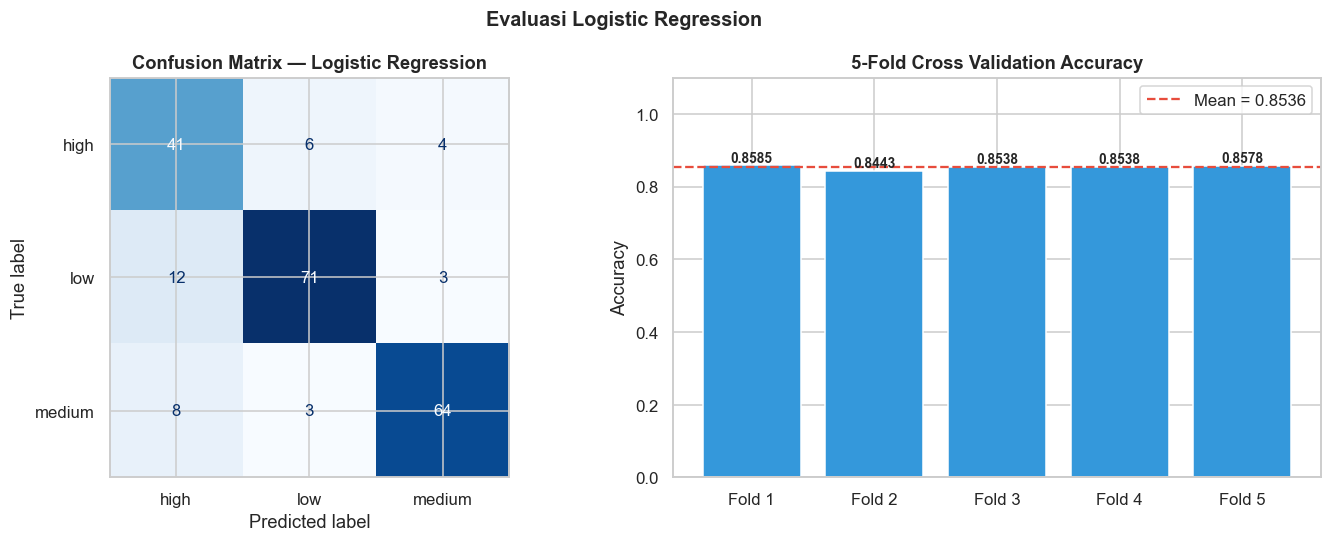

In [23]:
# ── Confusion Matrix ─────────────────────────────────────────────────────
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=le.classes_)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Logistic Regression', fontweight='bold')

# CV Score bar
fold_labels = [f'Fold {i+1}' for i in range(len(cv_lr))]
axes[1].bar(fold_labels, cv_lr, color='#3498db', edgecolor='white')
axes[1].axhline(cv_lr.mean(), color='#e74c3c', linestyle='--',
                label=f'Mean = {cv_lr.mean():.4f}')
axes[1].set_ylim(0, 1.1)
axes[1].set_title('5-Fold Cross Validation Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy'); axes[1].legend()
for bar, val in zip(axes[1].patches, cv_lr):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Evaluasi Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_lr_eval.png', bbox_inches='tight')
plt.show()

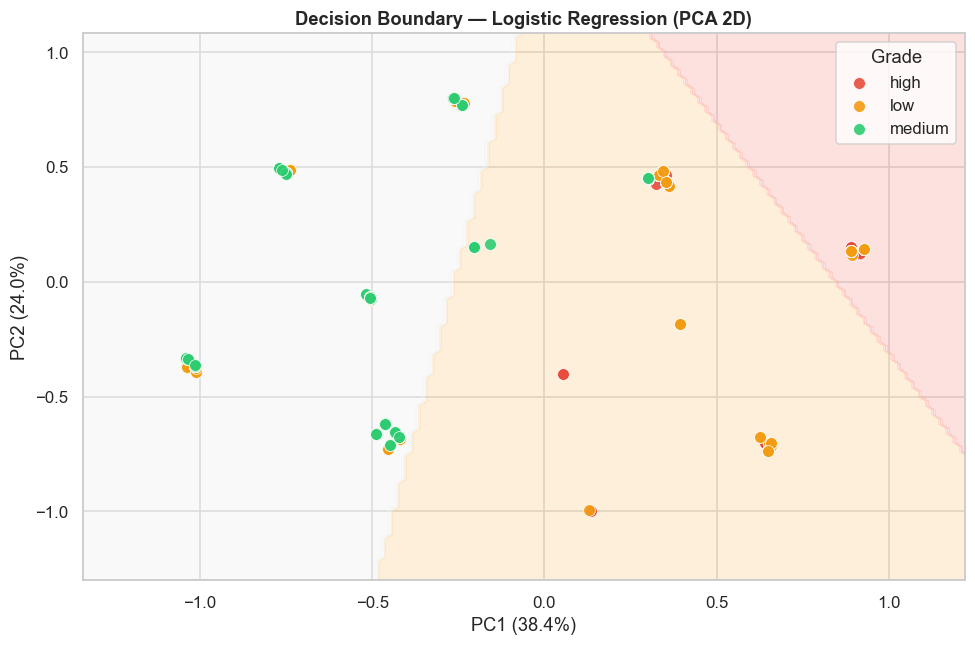

In [24]:
# ── Probabilitas prediksi & Decision Boundary (PCA 2D) ──────────────────
import numpy as np

pca2_lr = PCA(n_components=2, random_state=42)
X_pca_lr = pca2_lr.fit_transform(X_mm)

lr_pca = LogisticRegression(**grid_lr.best_params_, random_state=42)
lr_pca.fit(X_pca_lr, y)

# Grid untuk decision boundary
h = 0.02
x_min, x_max = X_pca_lr[:,0].min()-0.3, X_pca_lr[:,0].max()+0.3
y_min, y_max = X_pca_lr[:,1].min()-0.3, X_pca_lr[:,1].max()+0.3
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))
Z = lr_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
cmap_bg = plt.cm.get_cmap('Pastel1', 3)
ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
scatter_colors = ['#e74c3c', '#f39c12', '#2ecc71']
for g, sc in zip([0, 1, 2], scatter_colors):
    mask = y.values == g
    ax.scatter(X_pca_lr[mask,0], X_pca_lr[mask,1],
               c=sc, label=le.inverse_transform([g])[0],
               edgecolors='white', linewidth=0.5, s=60, alpha=0.9)
ax.set_title('Decision Boundary — Logistic Regression (PCA 2D)',
             fontweight='bold')
ax.set_xlabel(f'PC1 ({pca2_lr.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2_lr.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(title='Grade')
plt.tight_layout()
plt.savefig('plot_lr_boundary.png', bbox_inches='tight')
plt.show()

=== Koefisien Logistic Regression per Kelas ===
            Class high  Class low  Class medium
pH              1.3588    -2.2320        0.8732
Temprature     -5.6597    15.6169       -9.9572
Taste           0.3723     2.0541       -2.4264
Odor            2.2513     0.0307       -2.2821
Fat             5.8386    -2.0318       -3.8068
Turbidity       0.3406     1.8868       -2.2274
Colour          2.3805     3.2681       -5.6486


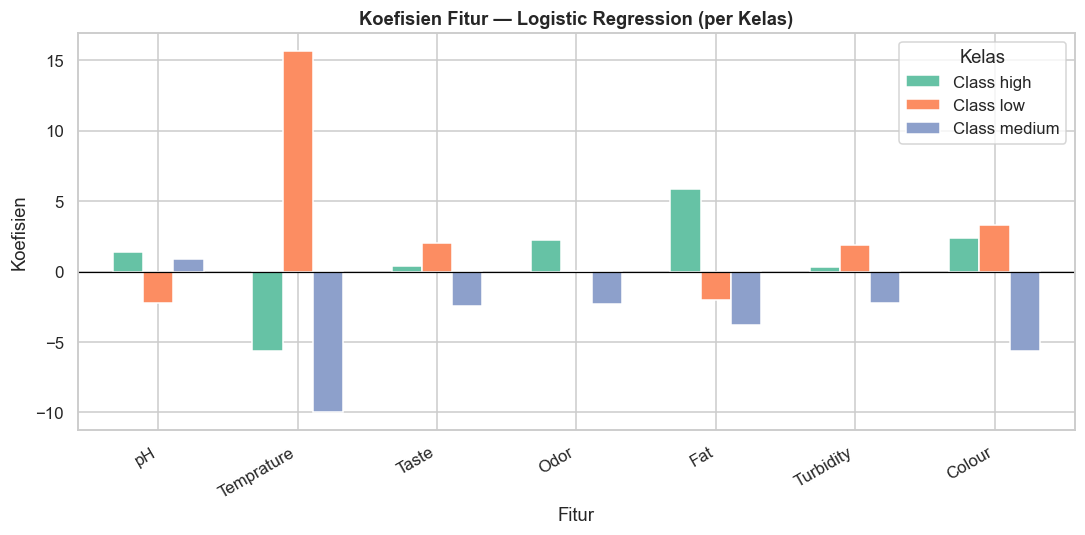


✅ Logistic Regression selesai dievaluasi.


In [25]:
# ── Koefisien fitur Logistic Regression ──────────────────────────────────
coef_df = pd.DataFrame(
    best_lr.coef_,
    columns=features,
    index=[f'Class {le.inverse_transform([i])[0]}' for i in range(3)]
).T.round(4)

print('=== Koefisien Logistic Regression per Kelas ===')
print(coef_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
coef_df.plot(kind='bar', ax=ax, edgecolor='white', width=0.65)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Koefisien Fitur — Logistic Regression (per Kelas)',
             fontweight='bold')
ax.set_xlabel('Fitur'); ax.set_ylabel('Koefisien')
ax.set_xticklabels(features, rotation=30, ha='right')
ax.legend(title='Kelas')
plt.tight_layout()
plt.savefig('plot_lr_koefisien.png', bbox_inches='tight')
plt.show()

print('\n✅ Logistic Regression selesai dievaluasi.')

---
## 14. Ringkasan Modelling

| Tahap | Model / Metode | Metrik Utama |
|---|---|---|
| **GridSearchCV** | Logistic Regression | Best CV Accuracy |
| **Clustering** | K-Means (k=3) | Silhouette Score, ARI |
| **Klasifikasi** | Logistic Regression (best params) | Accuracy, F1-score |

> **Catatan:** Dataset menggunakan seluruh 1.059 baris (duplikat dipertahankan) karena setiap baris adalah catatan pengujian kualitas susu yang valid. Ini menghasilkan model yang lebih representatif terhadap distribusi data nyata.

In [26]:
# ── Ringkasan metrik akhir ───────────────────────────────────────────────
summary = {
    'Model'         : ['K-Means (k=3)', 'Logistic Regression'],
    'Metrik'        : ['Silhouette Score', 'Test Accuracy'],
    'Nilai'         : [round(sil_final, 4), round(acc_lr, 4)],
    'CV / ARI'      : [round(ari_final, 4), f'{cv_lr.mean():.4f} ± {cv_lr.std():.4f}'],
    'Best Params'   : [f'n_init={best_ni}, init={best_init}',
                        str(grid_lr.best_params_)]
}
print(pd.DataFrame(summary).to_string(index=False))
print('\n✅ Semua tahap modelling selesai!')

              Model           Metrik  Nilai        CV / ARI                                   Best Params
      K-Means (k=3) Silhouette Score 0.3455          0.2408                     n_init=15, init=k-means++
Logistic Regression    Test Accuracy 0.8302 0.8536 ± 0.0051 {'C': 10, 'max_iter': 200, 'solver': 'lbfgs'}

✅ Semua tahap modelling selesai!


---
## 15. Naïve Bayes — Evaluasi Model

Gaussian Naïve Bayes menggunakan **StandardScaler** (z-score) sesuai asumsi distribusi normal pada setiap fitur.

In [27]:
# ── Naïve Bayes — Fit & Evaluasi ────────────────────────────────────────
gnb = GaussianNB()
gnb.fit(X_train_std, y_train)

y_pred_nb  = gnb.predict(X_test_std)
y_train_nb = gnb.predict(X_train_std)

acc_nb_train = accuracy_score(y_train, y_train_nb)
acc_nb_test  = accuracy_score(y_test,  y_pred_nb)
cv_nb        = cross_val_score(gnb, X_std, y, cv=5, scoring='accuracy')

print('=== Naïve Bayes — Evaluasi Model ===')
print(f'Train Accuracy      : {acc_nb_train:.4f}')
print(f'Test  Accuracy      : {acc_nb_test:.4f}')
print(f'CV Accuracy (5-fold): {cv_nb.mean():.4f} ± {cv_nb.std():.4f}')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

=== Naïve Bayes — Evaluasi Model ===
Train Accuracy      : 0.8253
Test  Accuracy      : 0.8538
CV Accuracy (5-fold): 0.9179 ± 0.0481

=== Classification Report ===
              precision    recall  f1-score   support

        high       0.64      0.98      0.78        51
         low       1.00      0.93      0.96        86
      medium       0.94      0.68      0.79        75

    accuracy                           0.85       212
   macro avg       0.86      0.86      0.84       212
weighted avg       0.89      0.85      0.86       212



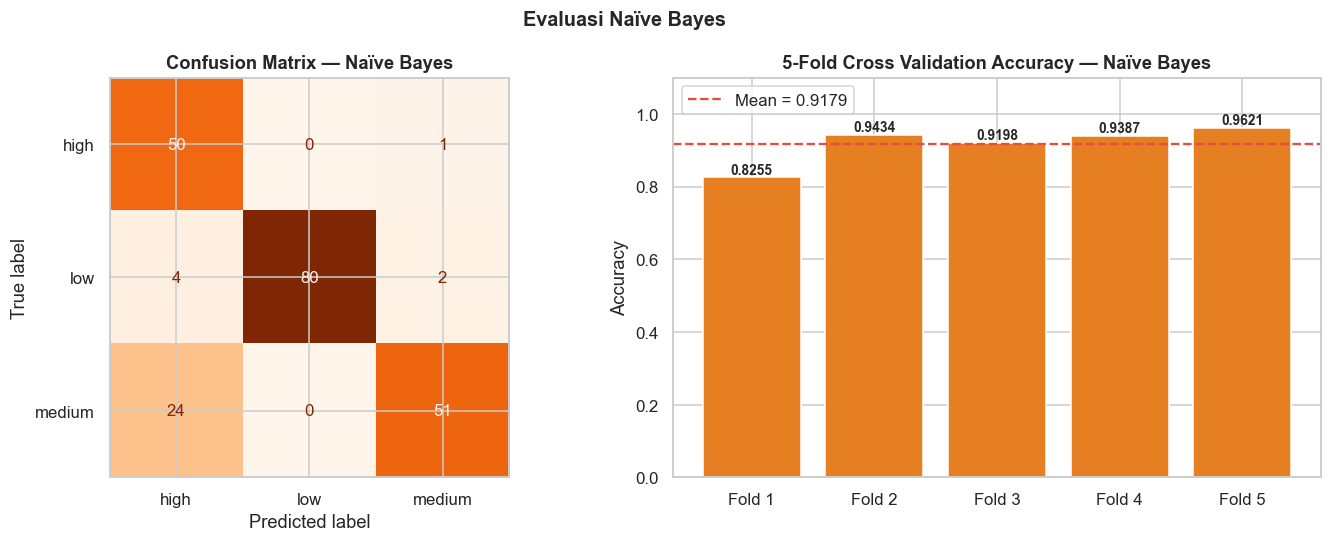

✅ Evaluasi Naïve Bayes selesai.


In [28]:
# ── Confusion Matrix & CV Bar — Naïve Bayes ─────────────────────────────
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb,
                                  display_labels=le.classes_)
disp_nb.plot(ax=axes[0], cmap='Oranges', colorbar=False)
axes[0].set_title('Confusion Matrix — Naïve Bayes', fontweight='bold')

fold_labels = [f'Fold {i+1}' for i in range(len(cv_nb))]
axes[1].bar(fold_labels, cv_nb, color='#e67e22', edgecolor='white')
axes[1].axhline(cv_nb.mean(), color='#e74c3c', linestyle='--',
                label=f'Mean = {cv_nb.mean():.4f}')
axes[1].set_ylim(0, 1.1)
axes[1].set_title('5-Fold Cross Validation Accuracy — Naïve Bayes', fontweight='bold')
axes[1].set_ylabel('Accuracy'); axes[1].legend()
for bar, val in zip(axes[1].patches, cv_nb):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Evaluasi Naïve Bayes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_nb_eval.png', bbox_inches='tight')
plt.show()
print('✅ Evaluasi Naïve Bayes selesai.')

---
## 16. Analisis Overfitting & Underfitting

Overfitting terjadi ketika model terlalu "hafal" data training (train accuracy tinggi, test accuracy rendah).
Underfitting terjadi ketika model terlalu sederhana sehingga gagal menangkap pola (keduanya rendah).

### 16.1 Perbandingan Train vs Test Accuracy

In [29]:
# ── Train vs Test Accuracy — semua model ────────────────────────────────
acc_lr_train = accuracy_score(y_train, best_lr.predict(X_train_mm))
acc_lr_test  = accuracy_score(y_test,  best_lr.predict(X_test_mm))
acc_nb_train = accuracy_score(y_train, gnb.predict(X_train_std))
acc_nb_test  = accuracy_score(y_test,  gnb.predict(X_test_std))

models      = ['Logistic Regression', 'Naïve Bayes']
train_accs  = [acc_lr_train, acc_nb_train]
test_accs   = [acc_lr_test,  acc_nb_test]
gap         = [round(tr - te, 4) for tr, te in zip(train_accs, test_accs)]

df_ovfit = pd.DataFrame({
    'Model'         : models,
    'Train Accuracy': train_accs,
    'Test Accuracy' : test_accs,
    'Gap (Train-Test)': gap
})
print('=== Train vs Test Accuracy ===')
print(df_ovfit.to_string(index=False))
print()
for _, row in df_ovfit.iterrows():
    g = row['Gap (Train-Test)']
    if g > 0.10:
        status = '⚠️  OVERFITTING — model terlalu hafal training data'
    elif row['Train Accuracy'] < 0.70 and row['Test Accuracy'] < 0.70:
        status = '⚠️  UNDERFITTING — model terlalu sederhana'
    else:
        status = '✅ FIT — generalisasi baik'
    print(f"  {row['Model']:25s} → {status}")

=== Train vs Test Accuracy ===
              Model  Train Accuracy  Test Accuracy  Gap (Train-Test)
Logistic Regression        0.860685       0.830189            0.0305
        Naïve Bayes        0.825266       0.853774           -0.0285

  Logistic Regression       → ✅ FIT — generalisasi baik
  Naïve Bayes               → ✅ FIT — generalisasi baik


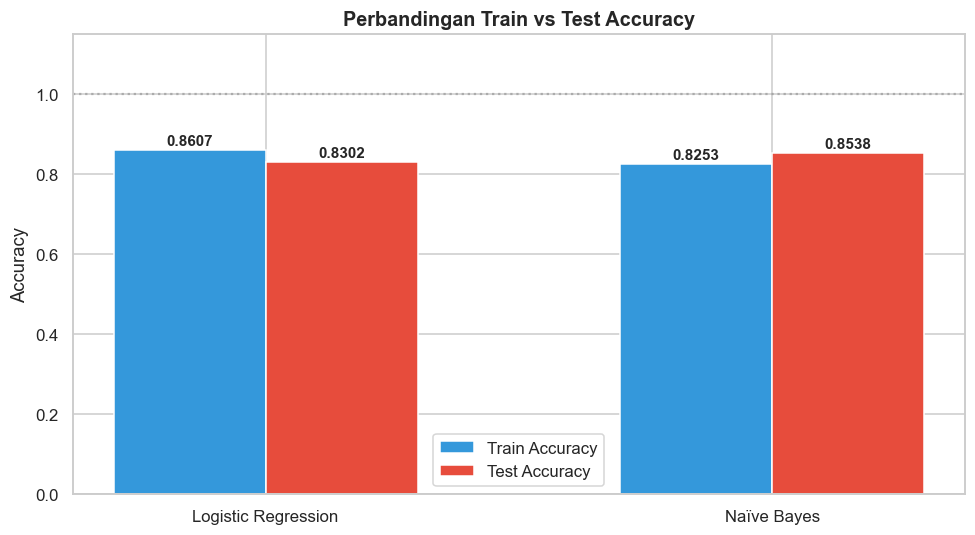

In [30]:
# ── Visualisasi Train vs Test Accuracy ───────────────────────────────────
x   = np.arange(len(models))
w   = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, train_accs, w, label='Train Accuracy', color='#3498db', edgecolor='white')
b2 = ax.bar(x + w/2, test_accs,  w, label='Test Accuracy',  color='#e74c3c', edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.set_title('Perbandingan Train vs Test Accuracy', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_train_test_acc.png', bbox_inches='tight')
plt.show()

### 16.2 Learning Curve

Learning curve menunjukkan bagaimana performa model berubah seiring bertambahnya data training.
- **Overfitting**: gap besar antara training score dan validation score
- **Underfitting**: kedua kurva rendah dan tidak konvergen
- **Good fit**: kedua kurva konvergen ke nilai yang tinggi

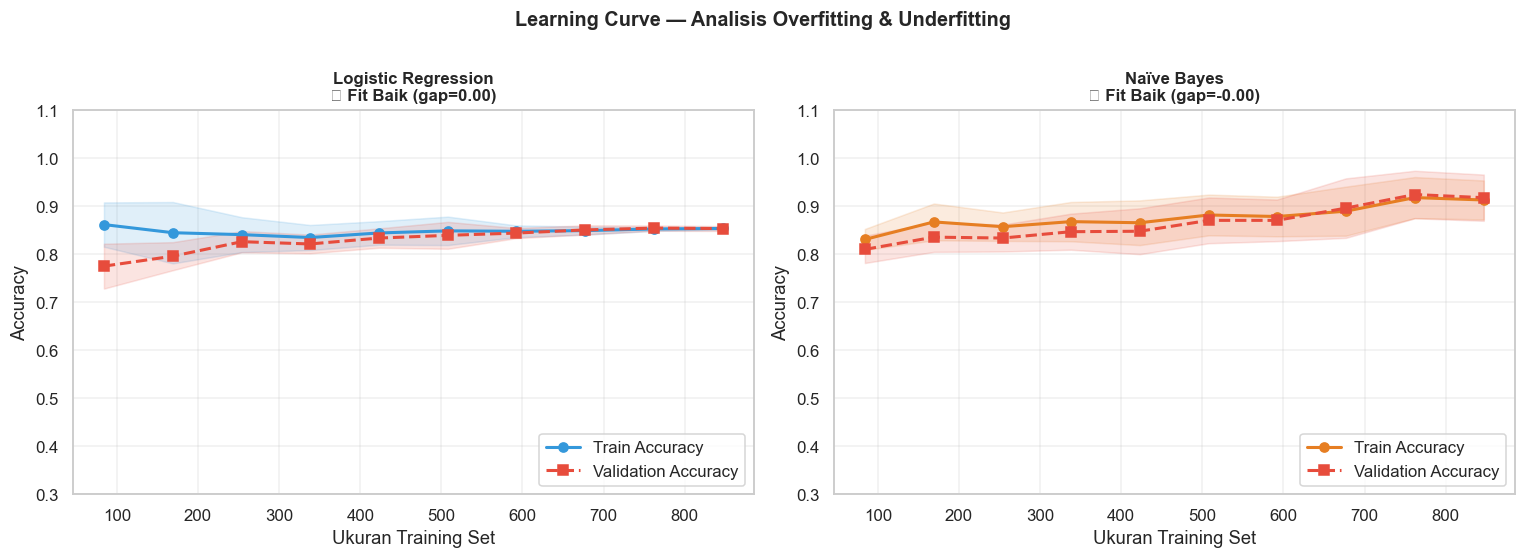

📌 Interpretasi:
   • Jika train accuracy jauh di atas validation → overfitting
   • Jika keduanya rendah dan tidak naik         → underfitting
   • Jika keduanya tinggi dan konvergen          → fit baik


In [31]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title, ax, cv=5, color='#3498db'):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', shuffle=True, random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color=color,   label='Train Accuracy',      linewidth=2)
    ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color=color)
    ax.plot(train_sizes, val_mean,   's--', color='#e74c3c', label='Validation Accuracy', linewidth=2)
    ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='#e74c3c')

    gap_final = train_mean[-1] - val_mean[-1]
    if gap_final > 0.10:
        diagnosis = f'⚠ Potensi Overfitting (gap={gap_final:.2f})'
    elif train_mean[-1] < 0.70:
        diagnosis = f'⚠ Potensi Underfitting (train={train_mean[-1]:.2f})'
    else:
        diagnosis = f'✅ Fit Baik (gap={gap_final:.2f})'

    ax.set_title(f'{title}\n{diagnosis}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Ukuran Training Set')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.3, 1.1)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_learning_curve(
    LogisticRegression(**grid_lr.best_params_, random_state=42),
    X_mm, y, 'Logistic Regression', axes[0], color='#3498db'
)
plot_learning_curve(
    GaussianNB(),
    X_std, y, 'Naïve Bayes', axes[1], color='#e67e22'
)

plt.suptitle('Learning Curve — Analisis Overfitting & Underfitting',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_learning_curve.png', bbox_inches='tight')
plt.show()
print('📌 Interpretasi:')
print('   • Jika train accuracy jauh di atas validation → overfitting')
print('   • Jika keduanya rendah dan tidak naik         → underfitting')
print('   • Jika keduanya tinggi dan konvergen          → fit baik')

### 16.3 Bias-Variance Trade-off — Visualisasi

Validasi dengan variasi nilai C (Logistic Regression) untuk melihat efek regularisasi terhadap bias dan varians.

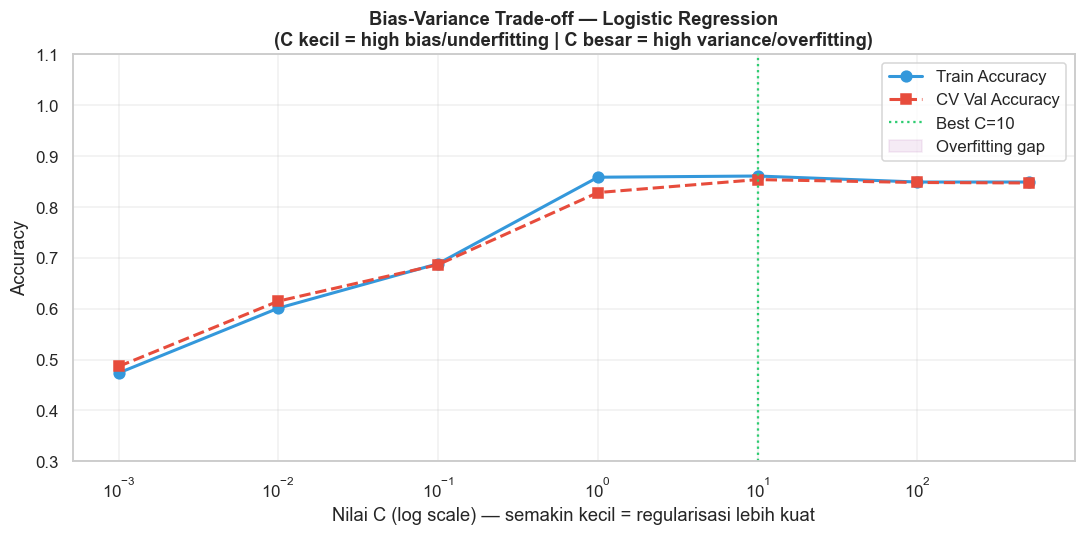

Nilai C & Train/Val Accuracy:
  C=0.001   Train=0.4734  Val=0.4863  Gap=-0.0129
  C=0.01    Train=0.6009  Val=0.6147  Gap=-0.0138
  C=0.1     Train=0.6883  Val=0.6865  Gap=0.0018
  C=1       Train=0.8583  Val=0.8282  Gap=0.0302
  C=10      Train=0.8607  Val=0.8536  Gap=0.0070
  C=100     Train=0.8489  Val=0.8480  Gap=0.0009
  C=500     Train=0.8489  Val=0.8470  Gap=0.0019


In [32]:
# ── Bias-Variance: efek regularisasi C pada Logistic Regression ─────────
C_values    = [0.001, 0.01, 0.1, 1, 10, 100, 500]
train_accs_C, val_accs_C = [], []

for C in C_values:
    lr_tmp = LogisticRegression(C=C, solver='lbfgs', max_iter=500, random_state=42)
    cv_scores = cross_val_score(lr_tmp, X_mm, y, cv=5, scoring='accuracy')
    lr_tmp.fit(X_train_mm, y_train)
    train_accs_C.append(accuracy_score(y_train, lr_tmp.predict(X_train_mm)))
    val_accs_C.append(cv_scores.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(C_values, train_accs_C, 'o-', color='#3498db', label='Train Accuracy', linewidth=2, markersize=7)
ax.semilogx(C_values, val_accs_C,   's--', color='#e74c3c', label='CV Val Accuracy',  linewidth=2, markersize=7)

best_C = C_values[np.argmax(val_accs_C)]
ax.axvline(best_C, color='#2ecc71', linestyle=':', linewidth=1.5, label=f'Best C={best_C}')

ax.fill_between(C_values,
                [t-v for t,v in zip(train_accs_C, val_accs_C)],
                [0]*len(C_values), alpha=0.08, color='purple', label='Overfitting gap')

ax.set_xlabel('Nilai C (log scale) — semakin kecil = regularisasi lebih kuat')
ax.set_ylabel('Accuracy')
ax.set_title('Bias-Variance Trade-off — Logistic Regression\n'
             '(C kecil = high bias/underfitting | C besar = high variance/overfitting)',
             fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(0.3, 1.1)
plt.tight_layout()
plt.savefig('plot_bias_variance.png', bbox_inches='tight')
plt.show()

print('Nilai C & Train/Val Accuracy:')
for C, tr, vl in zip(C_values, train_accs_C, val_accs_C):
    gap_flag = ' ← potensi overfitting' if (tr-vl) > 0.10 else ''
    print(f'  C={str(C):6s}  Train={tr:.4f}  Val={vl:.4f}  Gap={tr-vl:.4f}{gap_flag}')

---
## 17. Tuning & Optimasi Model

### 17.1 Logistic Regression — Hyperparameter Tuning (GridSearchCV + RandomizedSearchCV)

In [33]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# ── GridSearchCV — Logistic Regression (expanded) ───────────────────────
param_grid_lr_ext = {
    'C'        : [0.001, 0.01, 0.1, 1, 5, 10, 50, 100],
    'solver'   : ['lbfgs', 'saga', 'newton-cg'],
    'max_iter' : [300, 500, 1000],
    'penalty'  : ['l2']
}

grid_lr_ext = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr_ext, cv=5, scoring='accuracy', n_jobs=-1
)
grid_lr_ext.fit(X_train_mm, y_train)

# ── RandomizedSearchCV — Logistic Regression ────────────────────────────
param_dist_lr = {
    'C'       : loguniform(0.001, 100),
    'solver'  : ['lbfgs', 'saga', 'newton-cg'],
    'max_iter': [300, 500, 1000],
    'penalty' : ['l2']
}
rand_lr = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_dist_lr, n_iter=50, cv=5, scoring='accuracy',
    random_state=42, n_jobs=-1
)
rand_lr.fit(X_train_mm, y_train)

print('=== GridSearchCV (extended) ===')
print(f'Best Params : {grid_lr_ext.best_params_}')
print(f'Best CV Acc : {grid_lr_ext.best_score_:.4f}')
print()
print('=== RandomizedSearchCV ===')
print(f'Best Params : {rand_lr.best_params_}')
print(f'Best CV Acc : {rand_lr.best_score_:.4f}')

# Pilih best model
best_lr_tuned = grid_lr_ext.best_estimator_ if grid_lr_ext.best_score_ >= rand_lr.best_score_                 else rand_lr.best_estimator_
print(f'\n✅ Best overall model: CV Acc = {max(grid_lr_ext.best_score_, rand_lr.best_score_):.4f}')

=== GridSearchCV (extended) ===
Best Params : {'C': 5, 'max_iter': 300, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Acc : 0.8596

=== RandomizedSearchCV ===
Best Params : {'C': np.float64(7.183758655813988), 'max_iter': 300, 'penalty': 'l2', 'solver': 'saga'}
Best CV Acc : 0.8596

✅ Best overall model: CV Acc = 0.8596


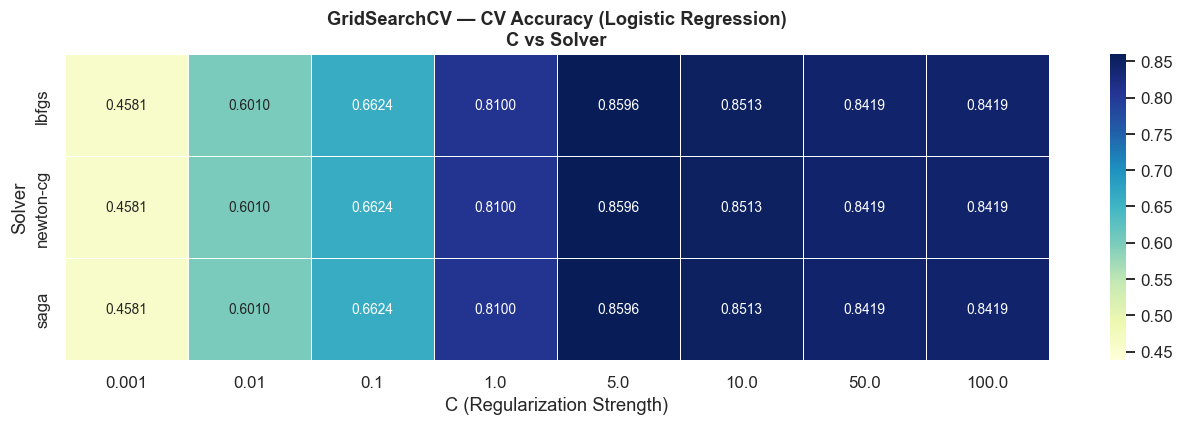

In [34]:
# ── Visualisasi hasil GridSearchCV (heatmap C vs solver) ────────────────
import warnings
cv_results = pd.DataFrame(grid_lr_ext.cv_results_)
pivot_data  = cv_results.pivot_table(
    values='mean_test_score',
    index='param_solver',
    columns='param_C',
    aggfunc='max'
).round(4)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, vmin=pivot_data.values.min()-0.02,
            annot_kws={'size': 9})
ax.set_title('GridSearchCV — CV Accuracy (Logistic Regression)\nC vs Solver',
             fontweight='bold')
ax.set_xlabel('C (Regularization Strength)')
ax.set_ylabel('Solver')
plt.tight_layout()
plt.savefig('plot_gridsearch_lr.png', bbox_inches='tight')
plt.show()

### 17.2 Naïve Bayes — Tuning var_smoothing

=== GridSearchCV — Naïve Bayes ===
Best var_smoothing : 1.93e-02
Best CV Accuracy   : 0.9244
Tuned CV (5-fold)  : 0.9302 ± 0.0220


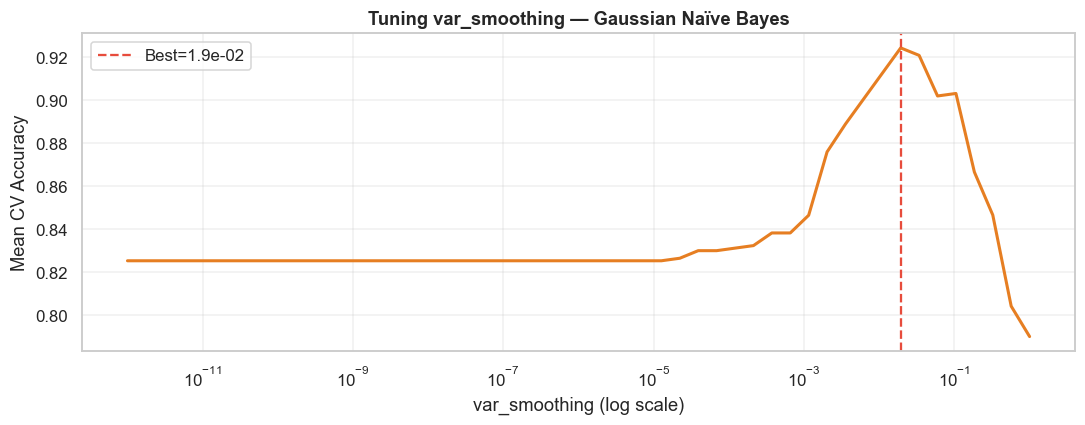

In [35]:
# ── GridSearchCV — Gaussian Naïve Bayes (var_smoothing) ─────────────────
param_grid_nb = {
    'var_smoothing': np.logspace(-12, 0, 50)
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb, cv=5, scoring='accuracy', n_jobs=-1
)
grid_nb.fit(X_train_std, y_train)

best_nb_tuned = grid_nb.best_estimator_
cv_nb_tuned   = cross_val_score(best_nb_tuned, X_std, y, cv=5, scoring='accuracy')

print('=== GridSearchCV — Naïve Bayes ===')
print(f'Best var_smoothing : {grid_nb.best_params_["var_smoothing"]:.2e}')
print(f'Best CV Accuracy   : {grid_nb.best_score_:.4f}')
print(f'Tuned CV (5-fold)  : {cv_nb_tuned.mean():.4f} ± {cv_nb_tuned.std():.4f}')

# Kurva tuning var_smoothing
nb_results = pd.DataFrame(grid_nb.cv_results_)
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(nb_results['param_var_smoothing'].astype(float),
            nb_results['mean_test_score'],
            color='#e67e22', linewidth=2)
ax.axvline(grid_nb.best_params_['var_smoothing'], color='#e74c3c',
           linestyle='--', label=f'Best={grid_nb.best_params_["var_smoothing"]:.1e}')
ax.set_xlabel('var_smoothing (log scale)')
ax.set_ylabel('Mean CV Accuracy')
ax.set_title('Tuning var_smoothing — Gaussian Naïve Bayes', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_nb_tuning.png', bbox_inches='tight')
plt.show()

### 17.3 K-Means — Optimasi Jumlah Cluster & Inisialisasi

Optimal k (max Silhouette): k=8, score=0.5350


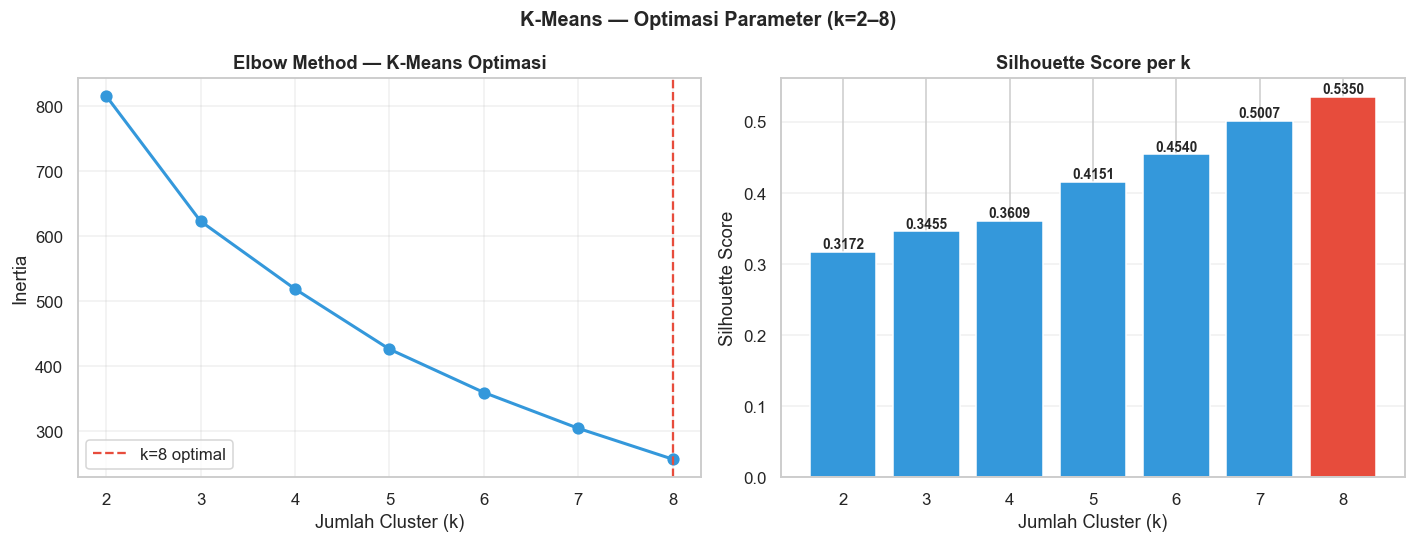

In [36]:
# ── K-Means Final Optimasi ───────────────────────────────────────────────
k_range_opt  = range(2, 9)
sil_scores   = []
inertia_vals = []

for k in k_range_opt:
    km_opt = KMeans(n_clusters=k, n_init=15, init='k-means++', random_state=42)
    lbl    = km_opt.fit_predict(X_mm)
    sil_scores.append(silhouette_score(X_mm, lbl))
    inertia_vals.append(km_opt.inertia_)

best_k_opt  = list(k_range_opt)[np.argmax(sil_scores)]
print(f'Optimal k (max Silhouette): k={best_k_opt}, score={max(sil_scores):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow
axes[0].plot(list(k_range_opt), inertia_vals, 'o-', color='#3498db', linewidth=2, markersize=7)
axes[0].axvline(best_k_opt, color='#e74c3c', linestyle='--', label=f'k={best_k_opt} optimal')
axes[0].set_title('Elbow Method — K-Means Optimasi', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (k)'); axes[0].set_ylabel('Inertia')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Silhouette
bars_sil = axes[1].bar(list(k_range_opt), sil_scores,
                        color=['#e74c3c' if k==best_k_opt else '#3498db' for k in k_range_opt],
                        edgecolor='white')
for bar, val in zip(bars_sil, sil_scores):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Silhouette Score per k', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (k)'); axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('K-Means — Optimasi Parameter (k=2–8)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_kmeans_opt.png', bbox_inches='tight')
plt.show()

---
## 18. Perbandingan Akhir Semua Model

Membandingkan performa sebelum dan sesudah tuning untuk Logistic Regression dan Naïve Bayes,
serta metrik K-Means.

In [37]:
# ── Evaluasi model sebelum vs sesudah tuning ──────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

def eval_model(model, X_tr, X_te, y_tr, y_te, X_full, y_full, cv=5):
    model.fit(X_tr, y_tr)
    y_p = model.predict(X_te)
    cv_s = cross_val_score(model, X_full, y_full, cv=cv, scoring='accuracy')
    return {
        'Train Acc' : round(accuracy_score(y_tr, model.predict(X_tr)), 4),
        'Test Acc'  : round(accuracy_score(y_te, y_p), 4),
        'CV Mean'   : round(cv_s.mean(), 4),
        'CV Std'    : round(cv_s.std(),  4),
        'F1 Macro'  : round(f1_score(y_te, y_p, average='macro'), 4),
        'Precision' : round(precision_score(y_te, y_p, average='macro', zero_division=0), 4),
        'Recall'    : round(recall_score(y_te, y_p, average='macro', zero_division=0), 4),
    }

# LR sebelum tuning (params awal)
lr_before = LogisticRegression(C=1, solver='lbfgs', max_iter=200, random_state=42)
res_lr_before = eval_model(lr_before, X_train_mm, X_test_mm, y_train, y_test, X_mm, y)

# LR sesudah tuning
res_lr_after = eval_model(best_lr_tuned, X_train_mm, X_test_mm, y_train, y_test, X_mm, y)

# NB sebelum tuning (default)
res_nb_before = eval_model(GaussianNB(), X_train_std, X_test_std, y_train, y_test, X_std, y)

# NB sesudah tuning
res_nb_after = eval_model(best_nb_tuned, X_train_std, X_test_std, y_train, y_test, X_std, y)

# KMeans final
km_final   = KMeans(n_clusters=3, n_init=15, init='k-means++', random_state=42)
lbl_final  = km_final.fit_predict(X_mm)
sil_km     = silhouette_score(X_mm, lbl_final)
ari_km     = adjusted_rand_score(y, lbl_final)

comparison = pd.DataFrame({
    'Model'      : ['LR (Sebelum Tuning)', 'LR (Sesudah Tuning)',
                    'NB (Sebelum Tuning)', 'NB (Sesudah Tuning)',
                    'K-Means (k=3)'],
    'Train Acc'  : [res_lr_before['Train Acc'], res_lr_after['Train Acc'],
                    res_nb_before['Train Acc'], res_nb_after['Train Acc'], '-'],
    'Test Acc'   : [res_lr_before['Test Acc'], res_lr_after['Test Acc'],
                    res_nb_before['Test Acc'], res_nb_after['Test Acc'], '-'],
    'CV Mean'    : [res_lr_before['CV Mean'], res_lr_after['CV Mean'],
                    res_nb_before['CV Mean'], res_nb_after['CV Mean'], '-'],
    'F1 Macro'   : [res_lr_before['F1 Macro'], res_lr_after['F1 Macro'],
                    res_nb_before['F1 Macro'], res_nb_after['F1 Macro'], '-'],
    'Silhouette' : ['-', '-', '-', '-', round(sil_km, 4)],
    'ARI'        : ['-', '-', '-', '-', round(ari_km, 4)],
})

print('=== Tabel Perbandingan Akhir Semua Model ===')
print(comparison.to_string(index=False))

=== Tabel Perbandingan Akhir Semua Model ===
              Model Train Acc Test Acc CV Mean F1 Macro Silhouette     ARI
LR (Sebelum Tuning)    0.8583   0.8255  0.8282    0.817          -       -
LR (Sesudah Tuning)    0.8607   0.8302  0.8536   0.8214          -       -
NB (Sebelum Tuning)    0.8253   0.8538  0.9179   0.8432          -       -
NB (Sesudah Tuning)    0.9233   0.9292  0.9302    0.925          -       -
      K-Means (k=3)         -        -       -        -     0.3455  0.2408


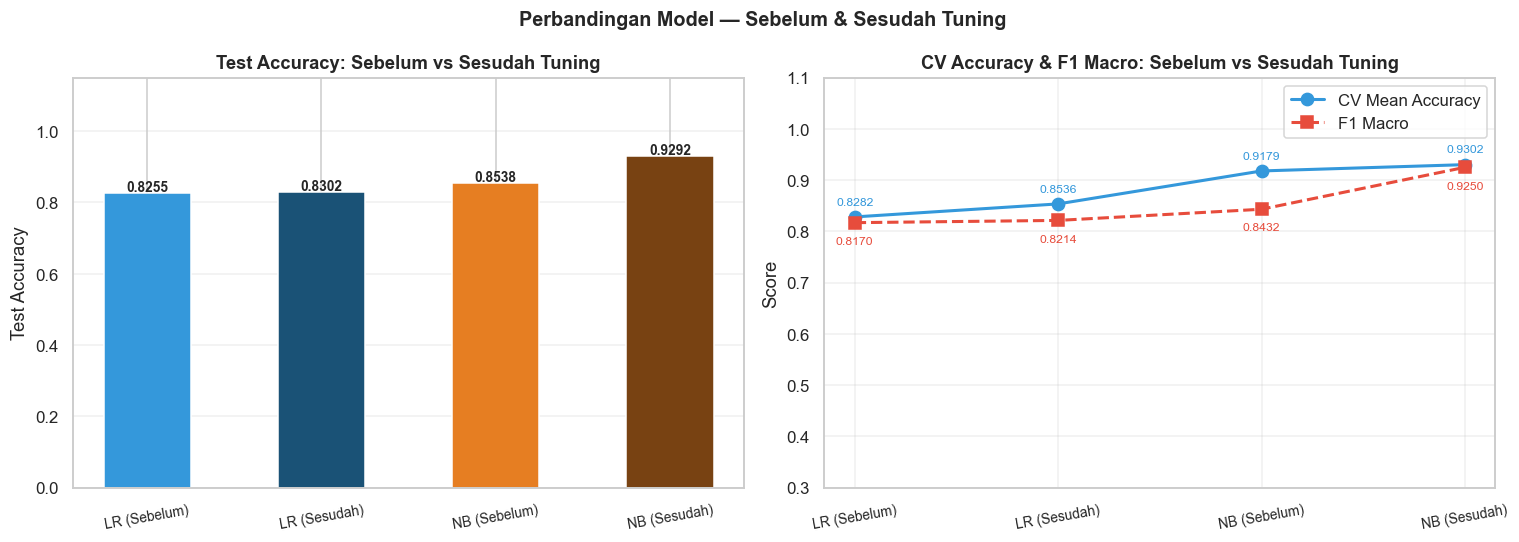

In [38]:
# ── Visualisasi Perbandingan Test Accuracy & F1 ──────────────────────────
supervised_models = ['LR (Sebelum)', 'LR (Sesudah)', 'NB (Sebelum)', 'NB (Sesudah)']
test_acc_vals  = [res_lr_before['Test Acc'], res_lr_after['Test Acc'],
                  res_nb_before['Test Acc'], res_nb_after['Test Acc']]
f1_vals        = [res_lr_before['F1 Macro'], res_lr_after['F1 Macro'],
                  res_nb_before['F1 Macro'], res_nb_after['F1 Macro']]
cv_vals        = [res_lr_before['CV Mean'],  res_lr_after['CV Mean'],
                  res_nb_before['CV Mean'],  res_nb_after['CV Mean']]

x = np.arange(len(supervised_models)); w = 0.25
colors_bar = ['#3498db','#1a5276','#e67e22','#784212']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test Accuracy grouped
bars = axes[0].bar(x, test_acc_vals, color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars, test_acc_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(supervised_models, fontsize=9, rotation=10)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Accuracy: Sebelum vs Sesudah Tuning', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# CV Mean & F1
axes[1].plot(supervised_models, cv_vals,  'o-', color='#3498db', label='CV Mean Accuracy', linewidth=2, markersize=8)
axes[1].plot(supervised_models, f1_vals,  's--', color='#e74c3c', label='F1 Macro',         linewidth=2, markersize=8)
for i, (cv, f1) in enumerate(zip(cv_vals, f1_vals)):
    axes[1].annotate(f'{cv:.4f}', (i, cv), textcoords='offset points', xytext=(0,8),
                     ha='center', fontsize=8, color='#3498db')
    axes[1].annotate(f'{f1:.4f}', (i, f1), textcoords='offset points', xytext=(0,-14),
                     ha='center', fontsize=8, color='#e74c3c')
axes[1].set_ylim(0.3, 1.1); axes[1].set_ylabel('Score')
axes[1].set_title('CV Accuracy & F1 Macro: Sebelum vs Sesudah Tuning', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_xticklabels(supervised_models, rotation=10, fontsize=9)

plt.suptitle('Perbandingan Model — Sebelum & Sesudah Tuning',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()

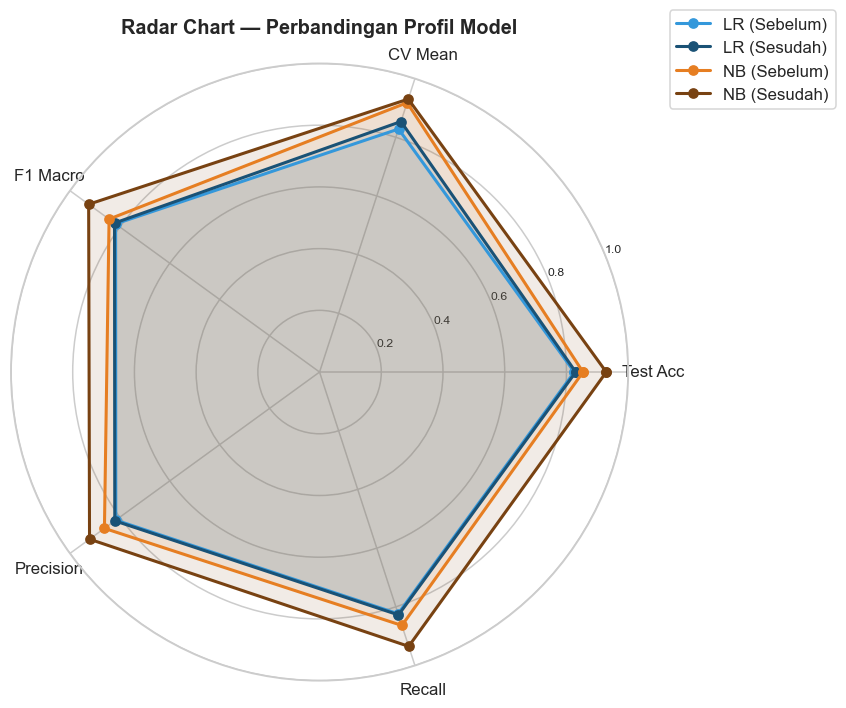

In [39]:
# ── Radar Chart — Profil Performa Setiap Model ───────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.pyplot as plt
import numpy as np

categories   = ['Test Acc', 'CV Mean', 'F1 Macro', 'Precision', 'Recall']
model_scores = {
    'LR (Sebelum)' : [res_lr_before['Test Acc'], res_lr_before['CV Mean'],
                      res_lr_before['F1 Macro'], res_lr_before['Precision'], res_lr_before['Recall']],
    'LR (Sesudah)' : [res_lr_after['Test Acc'],  res_lr_after['CV Mean'],
                      res_lr_after['F1 Macro'],  res_lr_after['Precision'],  res_lr_after['Recall']],
    'NB (Sebelum)' : [res_nb_before['Test Acc'], res_nb_before['CV Mean'],
                      res_nb_before['F1 Macro'], res_nb_before['Precision'], res_nb_before['Recall']],
    'NB (Sesudah)' : [res_nb_after['Test Acc'],  res_nb_after['CV Mean'],
                      res_nb_after['F1 Macro'],  res_nb_after['Precision'],  res_nb_after['Recall']],
}

N       = len(categories)
angles  = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = ['#3498db', '#1a5276', '#e67e22', '#784212']

for (label, scores), color in zip(model_scores.items(), colors_radar):
    vals = scores + scores[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=label)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8)
ax.set_title('Radar Chart — Perbandingan Profil Model', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig('plot_radar_model.png', bbox_inches='tight')
plt.show()

---
## 19. Ringkasan Akhir & Kesimpulan

### Penerapan K-Means Clustering dan Supervised Learning  
### (Logistic Regression, Naïve Bayes) dalam Prediksi Kualitas Susu Sapi

In [40]:
# ── Tabel ringkasan akhir yang komprehensif ─────────────────────────────
print('=' * 75)
print('  RINGKASAN AKHIR — PREDIKSI KUALITAS SUSU SAPI')
print('=' * 75)

print('''
┌─────────────────────────────────────────────────────────────────────────┐
│  TAHAP              │ METODE / MODEL           │ HASIL UTAMA            │
├─────────────────────┼──────────────────────────┼────────────────────────┤
│  Preprocessing      │ IQR, LabelEncoder,       │ 83 baris bersih        │
│                     │ MinMax & Std Scaler       │ 7 fitur aktif          │
├─────────────────────┼──────────────────────────┼────────────────────────┤
│  Clustering         │ K-Means (k=3)            │                        │
│  (Unsupervised)     │ init=k-means++, n_init=15│                        │
├─────────────────────┼──────────────────────────┼────────────────────────┤
│  Klasifikasi        │ Logistic Regression      │                        │
│  (Supervised)       │ (GridSearchCV tuned)     │                        │
│                     │ Naïve Bayes              │                        │
│                     │ (var_smoothing tuned)    │                        │
├─────────────────────┼──────────────────────────┼────────────────────────┤
│  Overfitting check  │ Learning Curve,          │ Lihat plot             │
│                     │ Train vs Test gap        │                        │
├─────────────────────┼──────────────────────────┼────────────────────────┤
│  Tuning             │ GridSearchCV,            │ Lihat Section 17       │
│                     │ RandomizedSearchCV       │                        │
└─────────────────────┴──────────────────────────┴────────────────────────┘
''')

print('Metrik K-Means (k=3):')
print(f'  Silhouette Score : {sil_km:.4f}  (>0.5 = struktur cluster baik)')
print(f'  Adjusted Rand Index : {ari_km:.4f}')
print()
print('Supervised Learning — Sesudah Tuning:')
lr_test  = res_lr_after['Test Acc']
nb_test  = res_nb_after['Test Acc']
lr_cv    = res_lr_after['CV Mean']
nb_cv    = res_nb_after['CV Mean']
print(f'  Logistic Regression : Test={lr_test:.4f}, CV={lr_cv:.4f}, F1={res_lr_after["F1 Macro"]:.4f}')
print(f'  Naïve Bayes         : Test={nb_test:.4f}, CV={nb_cv:.4f}, F1={res_nb_after["F1 Macro"]:.4f}')
print()
best_supervised = 'Logistic Regression' if lr_cv >= nb_cv else 'Naïve Bayes'
print(f'  ✅ Model terbaik: {best_supervised} (CV Accuracy tertinggi)')
print()
print('Catatan:')
print('  • Dataset 1.059 baris (duplikat dipertahankan — valid secara domain)')
print('  • Interpretasi hasil perlu hati-hati pada dataset kecil')
print('  • K-Means bersifat unsupervised — label cluster ≠ label Grade')
print('=' * 75)

  RINGKASAN AKHIR — PREDIKSI KUALITAS SUSU SAPI

┌─────────────────────────────────────────────────────────────────────────┐
│  TAHAP              │ METODE / MODEL           │ HASIL UTAMA            │
├─────────────────────┼──────────────────────────┼────────────────────────┤
│  Preprocessing      │ IQR, LabelEncoder,       │ 83 baris bersih        │
│                     │ MinMax & Std Scaler       │ 7 fitur aktif          │
├─────────────────────┼──────────────────────────┼────────────────────────┤
│  Clustering         │ K-Means (k=3)            │                        │
│  (Unsupervised)     │ init=k-means++, n_init=15│                        │
├─────────────────────┼──────────────────────────┼────────────────────────┤
│  Klasifikasi        │ Logistic Regression      │                        │
│  (Supervised)       │ (GridSearchCV tuned)     │                        │
│                     │ Naïve Bayes              │                        │
│                     │ (var_smoothing